# Nested-protocol elasticity benchmark

This notebook reads the nested protocol tables (OLS, Ridge, MLP, ICDN) with the same comparison rules as the paper. Panels: Walmart M5, 1C Predict Future Sales, and Dominick beer (a directory is used only if it exists).

- predictive comparisons use **matched cells**;
- cross-price comparisons use **matched edges**;
- bootstrap uncertainty is **series-level**, not a CI for a global parameter.

**ICDN vs MLP** is the main contrast. Two paired analyses sit on top of the per-model tables:

1. **Predictive inference.** Concatenate outer-validation predictions, form `d_ist = |y - y_hat_ICDN| - |y - y_hat_MLP|`, and week-block bootstrap ΔMAE without retraining. The non-inferiority margin delta = `PRED_NI_MARGIN` is a pre-specified design constant.
2. **Bootstrap stability.** For each series, use the **intersection** of bootstrap IDs in `bootstrap_replicates.csv`. ICDN cross-price `edge_selection_frequency` is reported separately from the SD of the elasticity when the edge is present.


In [2]:
from pathlib import Path
import json
import sys
import warnings

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

ROOT = Path.cwd() if Path.cwd().name != "notebooks" else Path.cwd().parent
sys.path.insert(0, str(ROOT))

from src.benchmarks.constants import (
    N_BOOT_ICDN,
    N_BOOT_LINEAR,
    N_BOOT_MLP,
    N_BOOT_PRED_INFER,
    N_FOLDS,
    N_TRIALS_ICDN,
    N_TRIALS_MLP,
    PRED_NI_MARGIN,
    SEED,
)
from src.benchmarks.paired import (
    ELAST_CLIP,
    best_complete_trial,
    clips_for,
    elasticity_clip_diagnostics,
    elasticity_distribution,
    share_obs_both,
)
from src.benchmarks.predict import COMPARE_MODELS, LINEAR_MODELS, NEURAL_MODELS
from src.benchmarks.reporting import concat_model_csv, rebuild_all

rebuild_all(ROOT)

PANELS = {
    "walmart": ROOT / "data" / "M5-walmart" / "panel",
    "dunnhumby": ROOT / "data" / "Dunnhumby" / "panel",
    "dominick": ROOT / "data" / "Dominick" / "panel",
}
PANELS = {k: v for k, v in PANELS.items() if v.exists()}
FIG = ROOT / "notebooks" / "figures"
FIG.mkdir(parents=True, exist_ok=True)

MODEL_ORDER = list(COMPARE_MODELS)
MODEL_LABEL = {"ols": "OLS", "ridge": "Ridge", "mlp": "MLP", "icdn": "ICDN"}
DATASET_LABEL = {
    "walmart": "Walmart M5 (FOODS_3)",
    "dunnhumby": "dunnhumby (COLD CEREAL)",
    "dominick": "Dominick (beer)",
}
KIND_LABEL = {"own": "own-price", "cross": "cross-price", "own_eq": "own-price (equation)"}
COLOR = {"ols": "#E69F00", "ridge": "#56B4E9", "mlp": "#009E73", "icdn": "#CC79A7"}
CONCLUSION_LABEL = {
    "icdn_superior": "ICDN superior (95% CI for ΔMAE lies below 0)",
    "mlp_superior": "MLP superior (95% CI for ΔMAE lies above 0)",
    "icdn_noninferior": "ICDN non-inferior (CI excludes ΔMAE ≥ δ)",
    "indistinguishable": "Indistinguishable at this sample",
    "undefined": "Undefined",
}

plt.rcParams.update({
    "figure.dpi": 130,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.22,
    "grid.linewidth": 0.6,
    "axes.axisbelow": True,
    "font.size": 10.5,
    "axes.titlesize": 11.5,
    "axes.labelsize": 10.5,
    "legend.frameon": False,
    "legend.fontsize": 9.5,
    "xtick.labelsize": 9.5,
    "ytick.labelsize": 9.5,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
})

print(
    f"N_FOLDS={N_FOLDS}  N_TRIALS_MLP={N_TRIALS_MLP}  N_TRIALS_ICDN={N_TRIALS_ICDN}  "
    f"N_BOOT linear/MLP/ICDN={N_BOOT_LINEAR}/{N_BOOT_MLP}/{N_BOOT_ICDN}  "
    f"N_BOOT_PRED_INFER={N_BOOT_PRED_INFER}  PRED_NI_MARGIN={PRED_NI_MARGIN}  SEED={SEED}"
)


/home/thebigmonster/Github/nn-elasticity-additional-work/venv-icdn/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



=== rebuild /home/thebigmonster/Github/nn-elasticity-additional-work/data/M5-walmart/panel

=== rebuild /home/thebigmonster/Github/nn-elasticity-additional-work/data/Dominick/panel
N_FOLDS=3  N_TRIALS_MLP=100  N_TRIALS_ICDN=100  N_BOOT linear/MLP/ICDN=100/100/100  N_BOOT_PRED_INFER=999  PRED_NI_MARGIN=0.05  SEED=42


In [3]:
def read_csv(path: Path) -> pd.DataFrame:
    if path is None or not path.exists():
        return pd.DataFrame()
    return pd.read_csv(path)


def load_all(name: str, panel: Path) -> pd.DataFrame:
    return concat_model_csv(panel, name)


def show_table(df: pd.DataFrame, caption: str, na="—", floatfmt=4):
    out = df.copy()
    for col in out.select_dtypes(include=["float", "float64", "float32"]).columns:
        out[col] = out[col].map(lambda x: na if pd.isna(x) else f"{x:.{floatfmt}f}")
    display(Markdown(f"**{caption}**"))
    print(out)
    return df


def savefig(fig, stem: str):
    fig.savefig(FIG / f"{stem}.pdf")
    fig.savefig(FIG / f"{stem}.png")
    print("  figure", FIG / f"{stem}.pdf")


def present_folds(kfold: pd.DataFrame) -> set[str]:
    if kfold.empty or "fold" not in kfold.columns:
        return set()
    return set(kfold["fold"].astype(str))


def inventory(panel: Path) -> pd.DataFrame:
    rows = []
    expected = [
        "kfold.csv", "kfold_series.csv", "kfold_series_stats.csv",
        "holdout_pred_cells.csv", "holdout_elasticities.csv",
        "bootstrap.csv", "bootstrap_replicates.csv", "bootstrap_series_ci.csv",
        "bootstrap_matched.csv", "bootstrap_matched_global.csv",
        "holdout_in_boot_ci.csv", "boot_fold_ratio.csv", "fold_in_boot_ci.csv",
        "bootstrap_manifest.json",
    ]
    shared = [
        "matched_prediction_metrics.csv", "matched_elasticity_series.csv",
        "pred_matched_kfold.csv", "pred_matched_holdout.csv",
        "edge_matched_kfold.csv", "edge_matched_kfold_sd.csv", "edge_matched_kfold_coverage.csv",
        "paired_bootstrap_stability.csv", "paired_bootstrap_summary.csv",
        "paired_predictive_inference.csv", "paired_predictive_series.csv",
        "split_plan.json", "split_plan.csv", "bootstrap_plan.json",
        "run_manifest.csv", "bootstrap_manifest.csv", "run_failures.csv",
        "spline_support_diagnostics.csv",
    ]
    for model in MODEL_ORDER:
        mdir = panel / model
        for name in expected:
            rows.append({"model": model, "file": name, "present": (mdir / name).exists()})
        for path in sorted(mdir.glob("fold*_pred_cells.csv")):
            rows.append({"model": model, "file": path.name, "present": True})
        for path in sorted(mdir.glob("fold*_elasticities_long.csv")):
            rows.append({"model": model, "file": path.name, "present": True})
        for path in sorted(mdir.glob("fold*_pred_ij.csv")):
            rows.append({"model": model, "file": path.name, "present": True})
        for path in sorted(mdir.glob("*/optuna_trials.csv")):
            rows.append({"model": model, "file": str(path.relative_to(mdir)), "present": True})
    for name in shared:
        rows.append({"model": "(panel)", "file": name, "present": (panel / name).exists()})
    return pd.DataFrame(rows)


## 0. Inventory

Before interpreting a statistic, check which files exist. Missing neural holdout or bootstrap files are gaps, not zeros. `bootstrap_plan.json` is the shared draw for the dataset; `bootstrap_manifest.csv` flattens per-model audit JSON.


In [4]:
for key, panel in PANELS.items():
    inv = inventory(panel)
    missing = inv[~inv["present"]]
    print(f"\n=== {DATASET_LABEL[key]} ===")
    print("present", int(inv["present"].sum()), "/", len(inv), "rows")
    if len(missing):
        show_table(missing[["model", "file"]], "Missing files (not interpreted as zeros)")
    else:
        print("no expected files missing")
    kfold = load_all("kfold.csv", panel)
    if len(kfold):
        print("folds in kfold.csv:", sorted(kfold.groupby("model")["fold"].apply(lambda s: sorted(s.unique())).to_dict().items()))



=== Walmart M5 (FOODS_3) ===
present 106 / 106 rows
no expected files missing
folds in kfold.csv: [('icdn', [np.int64(1), np.int64(2), np.int64(3)]), ('mlp', [np.int64(1), np.int64(2), np.int64(3)]), ('ols', [np.int64(1), np.int64(2), np.int64(3)]), ('ridge', [np.int64(1), np.int64(2), np.int64(3)])]

=== dunnhumby (COLD CEREAL) ===
present 106 / 106 rows
no expected files missing
folds in kfold.csv: [('icdn', [np.int64(1), np.int64(2), np.int64(3)]), ('mlp', [np.int64(1), np.int64(2), np.int64(3)]), ('ols', [np.int64(1), np.int64(2), np.int64(3)]), ('ridge', [np.int64(1), np.int64(2), np.int64(3)])]

=== Dominick (beer) ===
present 106 / 106 rows
no expected files missing
folds in kfold.csv: [('icdn', [np.int64(1), np.int64(2), np.int64(3)]), ('mlp', [np.int64(1), np.int64(2), np.int64(3)]), ('ols', [np.int64(1), np.int64(2), np.int64(3)]), ('ridge', [np.int64(1), np.int64(2), np.int64(3)])]


## 1. Outer-fold prediction (native)

`kfold.csv` summarises each dataset–model–fold on the cells that model can predict. `cross_mean` is the average over that **native** pair set and is not comparable across models: ICDN estimates a neighbourhood, MLP the full Jacobian, OLS/Ridge the equations that pass VIF/d.f. gates.

The MAE figure shows time variation across outer folds. Coverage and compute stay in the table so the chart is not a mix of seconds, GPU-hours, and trial counts.


In [5]:
def kfold_prediction_table(kfold: pd.DataFrame) -> pd.DataFrame:
    cols = [
        "dataset", "model", "fold", "mae_val", "rmse_val", "r2_val",
        "n_cells", "n_validation_cells", "prediction_coverage",
        "n_own", "n_cross", "own_mean", "cross_mean",
        "n_parameters", "completed_trials", "pruned_trials", "failed_trials",
        "tuning_seconds", "fit_seconds", "gpu_hours",
    ]
    keep = [c for c in cols if c in kfold.columns]
    out = kfold[keep].copy()
    out["model"] = pd.Categorical(out["model"], MODEL_ORDER, ordered=True)
    return out.sort_values(["dataset", "fold", "model"])


parts = []
for k, p in PANELS.items():
    df = load_all("kfold.csv", p)
    if len(df):
        parts.append(df)
all_kfold = pd.concat(parts, ignore_index=True) if parts else pd.DataFrame()
show_table(kfold_prediction_table(all_kfold), "Table 1. Native metrics by outer fold")


**Table 1. Native metrics by outer fold**

      dataset  model  fold mae_val rmse_val  r2_val  n_cells  \
24   dominick    ols     1  0.4200   0.5609  0.8103    14188   
27   dominick  ridge     1  0.4205   0.5627  0.8091    14188   
30   dominick    mlp     1  0.4299   0.5685  0.8051    14188   
33   dominick   icdn     1  0.7655   0.9770  0.4245    14188   
25   dominick    ols     2  0.4605   0.6174  0.7807    14246   
28   dominick  ridge     2  0.4598   0.6151  0.7824    14246   
31   dominick    mlp     2  0.4393   0.5630  0.8176    14246   
34   dominick   icdn     2  0.5668   0.7436  0.6819    14246   
26   dominick    ols     3  0.4904   0.6368  0.7604    14851   
29   dominick  ridge     3  0.4803   0.6282  0.7669    14851   
32   dominick    mlp     3  0.4744   0.6041  0.7844    14851   
35   dominick   icdn     3  0.5220   0.6448  0.7544    14851   
12  dunnhumby    ols     1  0.3811   0.5128  0.6740    17812   
15  dunnhumby  ridge     1  0.3735   0.5076  0.6805    17812   
18  dunnhumby    mlp     1  0.4189   0.5

,dataset,model,fold,mae_val,rmse_val,r2_val,n_cells,n_validation_cells,prediction_coverage,n_own,n_cross,own_mean,cross_mean,n_parameters,completed_trials,pruned_trials,failed_trials,tuning_seconds,fit_seconds,gpu_hours
24,dominick,ols,1,0.420040,0.560876,0.810335,14188,14188,1.000000,400,7113,-4.636185,0.272739,41524,0,0,0,0.000000,50.655156,0.000000
27,dominick,ridge,1,0.420459,0.562662,0.809125,14188,14188,1.000000,400,7113,-3.676340,0.013114,41524,0,0,0,0.000000,86.701643,0.000000
30,dominick,mlp,1,0.429882,0.568494,0.805148,14188,14188,1.000000,400,7600,-0.952537,-0.042994,182308,56,44,0,386.376809,2.534494,0.108031
33,dominick,icdn,1,0.765493,0.976966,0.424542,14188,14188,1.000000,400,1600,-1.703868,0.891633,21165,34,66,0,1212.036998,9.058391,0.339193
25,dominick,ols,2,0.460508,0.617410,0.780732,14246,14246,1.000000,400,7099,-4.767625,0.163331,41558,0,0,0,0.000000,50.840440,0.000000
28,dominick,ridge,2,0.459771,0.615114,0.782360,14246,14246,1.000000,400,7099,-3.932281,0.003453,41558,0,0,0,0.000000,86.342768,0.000000
31,dominick,mlp,2,0.439321,0.563042,0.817649,14246,14246,1.000000,400,7600,-0.823185,-0.035085,182308,44,56,0,411.854196,3.272415,0.115313
34,dominick,icdn,2,0.566839,0.743629,0.681918,14246,14246,1.000000,400,800,-2.484259,1.095136,22262,28,72,0,1540.941903,8.230491,0.430326
26,dominick,ols,3,0.490357,0.636826,0.760413,14851,14851,1.000000,400,7151,-4.696004,0.065421,41847,0,0,0,0.000000,51.288430,0.000000
29,dominick,ridge,3,0.480335,0.628188,0.766869,14851,14851,1.000000,400,7151,-3.990504,0.000148,41847,0,0,0,0.000000,87.062180,0.000000


  figure /home/thebigmonster/Github/nn-elasticity-additional-work/notebooks/figures/walmart_kfold_mae.pdf


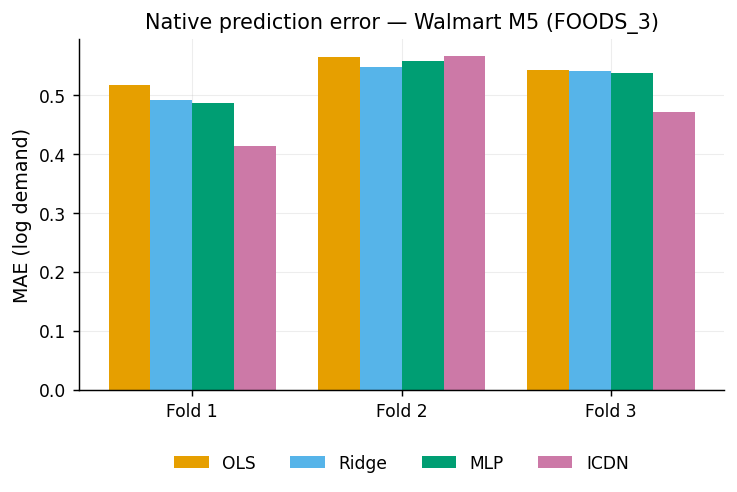

  figure /home/thebigmonster/Github/nn-elasticity-additional-work/notebooks/figures/walmart_kfold_coverage.pdf


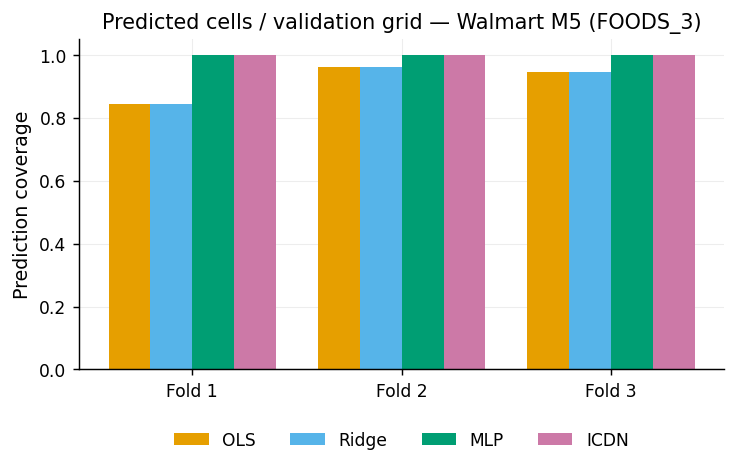

  figure /home/thebigmonster/Github/nn-elasticity-additional-work/notebooks/figures/dunnhumby_kfold_mae.pdf


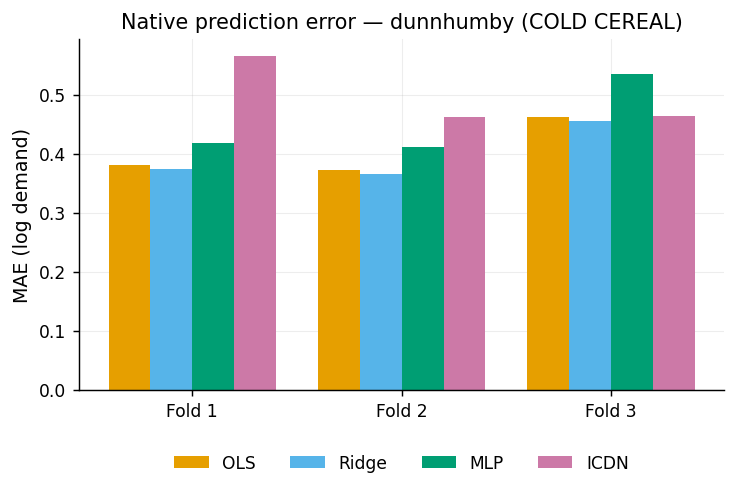

  figure /home/thebigmonster/Github/nn-elasticity-additional-work/notebooks/figures/dunnhumby_kfold_coverage.pdf


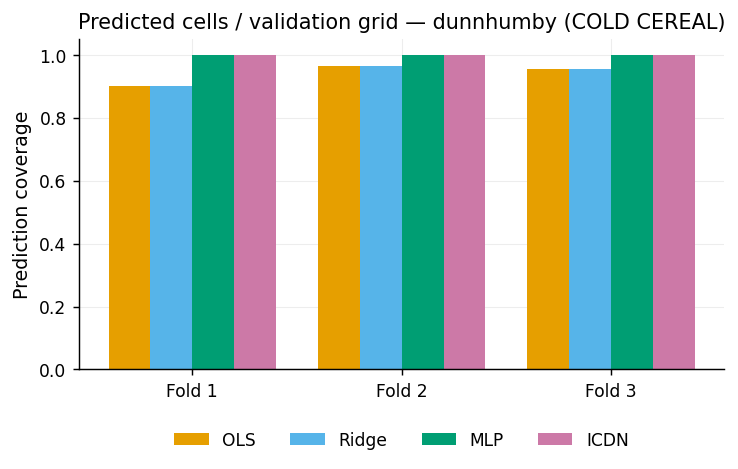

  figure /home/thebigmonster/Github/nn-elasticity-additional-work/notebooks/figures/dominick_kfold_mae.pdf


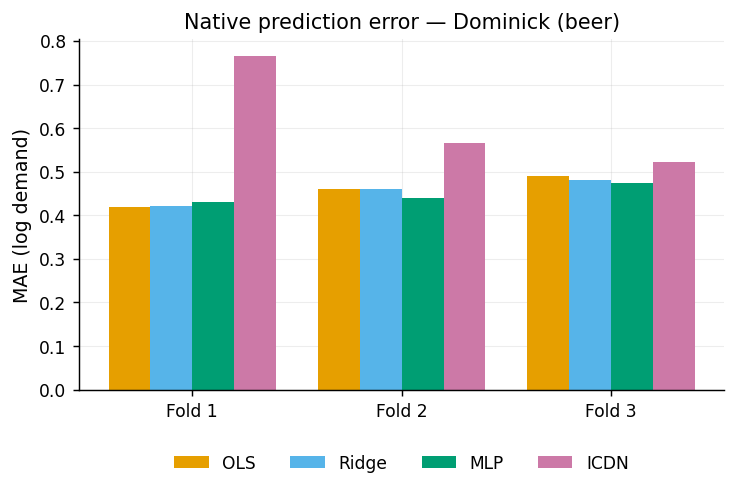

  figure /home/thebigmonster/Github/nn-elasticity-additional-work/notebooks/figures/dominick_kfold_coverage.pdf


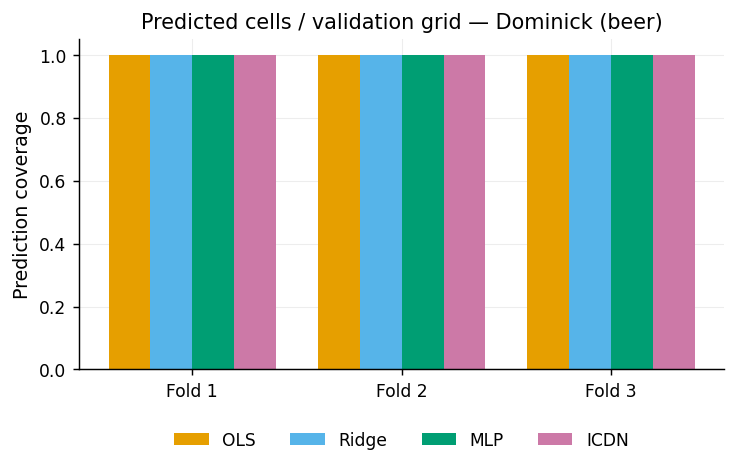

**Table 2. Prediction, Optuna budget, and compute (sums over folds)**

      dataset  model  n_folds mae_mean  mae_sd r2_mean coverage_mean  \
0    dominick   icdn        3   0.6181  0.1296  0.6203        1.0000   
1    dominick    mlp        3   0.4479  0.0235  0.8024        1.0000   
2    dominick    ols        3   0.4570  0.0353  0.7838        1.0000   
3    dominick  ridge        3   0.4535  0.0304  0.7861        1.0000   
4   dunnhumby   icdn        3   0.4974  0.0592  0.4618        1.0000   
5   dunnhumby    mlp        3   0.4552  0.0695  0.5518        1.0000   
6   dunnhumby    ols        3   0.4058  0.0497  0.6270        0.9410   
7   dunnhumby  ridge        3   0.3985  0.0499  0.6339        0.9410   
8     walmart   icdn        3   0.4843  0.0770  0.6893        1.0000   
9     walmart    mlp        3   0.5283  0.0367  0.6404        1.0000   
10    walmart    ols        3   0.5418  0.0230  0.4355        0.9169   
11    walmart  ridge        3   0.5277  0.0306  0.5510        0.9169   

   n_parameters  completed_trials  pruned_trials  failed_trials

,dataset,model,n_folds,mae_mean,mae_sd,r2_mean,coverage_mean,n_parameters,completed_trials,pruned_trials,failed_trials,fit_seconds,gpu_hours
0,dominick,icdn,3,0.618104,0.129598,0.620286,1.000000,21552.000000,110,190,0,38.680215,1.472190
1,dominick,mlp,3,0.447865,0.023453,0.802397,1.000000,182308.000000,155,145,0,8.468936,0.358659
2,dominick,ols,3,0.456968,0.035292,0.783827,1.000000,41643.000000,0,0,0,152.784026,0.000000
3,dominick,ridge,3,0.453522,0.030423,0.786118,1.000000,41643.000000,0,0,0,260.106592,0.000000
4,dunnhumby,icdn,3,0.497427,0.059240,0.461827,1.000000,22453.333333,127,173,0,79.646491,3.507314
5,dunnhumby,mlp,3,0.455179,0.069478,0.551767,1.000000,70916.666667,114,186,0,11.692602,0.459867
6,dunnhumby,ols,3,0.405776,0.049668,0.627010,0.940956,37478.000000,0,0,0,140.097643,0.000000
7,dunnhumby,ridge,3,0.398458,0.049868,0.633919,0.940956,37478.000000,0,0,0,226.141799,0.000000
8,walmart,icdn,3,0.484279,0.077024,0.689332,1.000000,34245.000000,90,210,0,38.543661,1.097555
9,walmart,mlp,3,0.528325,0.036703,0.640417,1.000000,166788.000000,120,180,0,5.348854,0.198129


In [6]:
def plot_mae_by_fold(kfold: pd.DataFrame, dataset: str, stem: str):
    df = kfold[kfold["dataset"] == dataset].copy()
    if df.empty:
        return
    folds = sorted(df["fold"].unique())
    fig, ax = plt.subplots(figsize=(6.4, 3.5))
    width = 0.8 / max(len(MODEL_ORDER), 1)
    x = np.arange(len(folds))
    for i, model in enumerate(MODEL_ORDER):
        part = df[df["model"] == model].set_index("fold")
        vals = [part.loc[f, "mae_val"] if f in part.index else np.nan for f in folds]
        ax.bar(x + (i - 1.5) * width, vals, width=width, color=COLOR[model], label=MODEL_LABEL[model])
    ax.set_xticks(x)
    ax.set_xticklabels([f"Fold {f}" for f in folds])
    ax.set_ylabel("MAE (log demand)")
    ax.set_title(f"Native prediction error — {DATASET_LABEL[dataset]}")
    ax.legend(ncol=4, loc="upper center", bbox_to_anchor=(0.5, -0.14))
    savefig(fig, stem)
    plt.show()
    plt.close(fig)


def plot_coverage(kfold: pd.DataFrame, dataset: str, stem: str):
    df = kfold[kfold["dataset"] == dataset].copy()
    if df.empty or "prediction_coverage" not in df.columns:
        return
    folds = sorted(df["fold"].unique())
    fig, ax = plt.subplots(figsize=(6.4, 3.3))
    width = 0.8 / max(len(MODEL_ORDER), 1)
    x = np.arange(len(folds))
    for i, model in enumerate(MODEL_ORDER):
        part = df[df["model"] == model].set_index("fold")
        vals = [part.loc[f, "prediction_coverage"] if f in part.index else np.nan for f in folds]
        ax.bar(x + (i - 1.5) * width, vals, width=width, color=COLOR[model], label=MODEL_LABEL[model])
    ax.set_xticks(x)
    ax.set_xticklabels([f"Fold {f}" for f in folds])
    ax.set_ylabel("Prediction coverage")
    ax.set_ylim(0, 1.05)
    ax.set_title(f"Predicted cells / validation grid — {DATASET_LABEL[dataset]}")
    ax.legend(ncol=4, loc="upper center", bbox_to_anchor=(0.5, -0.14))
    savefig(fig, stem)
    plt.show()
    plt.close(fig)


for key in PANELS:
    sub = all_kfold[all_kfold["dataset"] == key]
    if sub.empty:
        continue
    plot_mae_by_fold(all_kfold, key, f"{key}_kfold_mae")
    plot_coverage(all_kfold, key, f"{key}_kfold_coverage")

cost = all_kfold.groupby(["dataset", "model"], as_index=False).agg(
    n_folds=("fold", "nunique"),
    mae_mean=("mae_val", "mean"),
    mae_sd=("mae_val", "std"),
    r2_mean=("r2_val", "mean"),
    coverage_mean=("prediction_coverage", "mean"),
    n_parameters=("n_parameters", "mean"),
    completed_trials=("completed_trials", "sum"),
    pruned_trials=("pruned_trials", "sum"),
    failed_trials=("failed_trials", "sum"),
    fit_seconds=("fit_seconds", "sum"),
    gpu_hours=("gpu_hours", "sum"),
)
show_table(cost, "Table 2. Prediction, Optuna budget, and compute (sums over folds)")


## 2. Matched-cell prediction

`fold{k}_pred_cells.csv` is the validation grid with `y_true` and `y_pred` (NaN if the model does not predict that cell). Native MAE uses finite cells of each model; matched MAE uses the intersection.

`matched_prediction_metrics.csv` compares model pairs on the same observations. ΔMAE = MAE_a - MAE_b; negative favours a. Fold-level ΔMAE is a point contrast only — Section 3 puts a CI on the pooled ICDN–MLP difference.


In [7]:
def error_by_group(grid: pd.DataFrame, group: str) -> pd.DataFrame:
    g = grid.dropna(subset=["y_true", "y_pred"]).copy()
    g["abs_err"] = (g["y_true"] - g["y_pred"]).abs()
    return g.groupby(group, as_index=False).agg(mae=("abs_err", "mean"), n=("abs_err", "size"))


def pred_cells(panel: Path, model: str, fold) -> pd.DataFrame:
    name = "holdout_pred_cells.csv" if str(fold) == "holdout" else f"fold{fold}_pred_cells.csv"
    return read_csv(panel / model / name)


matched_pred = pd.concat(
    [read_csv(p / "matched_prediction_metrics.csv") for p in PANELS.values()],
    ignore_index=True,
)
if len(matched_pred):
    icdn_mlp = matched_pred[(matched_pred["model_a"] == "icdn") & (matched_pred["model_b"] == "mlp")]
    show_table(
        icdn_mlp[["dataset", "fold", "n_common_cells", "mae_a", "mae_b", "rmse_a", "rmse_b", "r2_a", "r2_b", "delta_mae", "delta_rmse", "delta_r2"]],
        "Table 3. ICDN vs MLP on matched cells (a = ICDN, b = MLP)",
    )
    show_table(
        matched_pred[matched_pred["fold"].astype(str) != "holdout"][
            ["dataset", "fold", "model_a", "model_b", "n_common_cells", "mae_a", "mae_b", "delta_mae", "r2_a", "r2_b"]
        ].sort_values(["dataset", "fold", "model_a", "model_b"]),
        "Table 4. All matched-cell pairs (outer folds)",
    )


**Table 3. ICDN vs MLP on matched cells (a = ICDN, b = MLP)**

      dataset     fold  n_common_cells   mae_a   mae_b  rmse_a  rmse_b  \
0     walmart        1            8217  0.4145  0.4876  0.5748  0.6674   
6     walmart        2            7268  0.5669  0.5590  0.7878  0.7679   
12    walmart        3            7297  0.4714  0.5384  0.6522  0.7394   
18    walmart  holdout            8453  0.5176  0.5736  0.6889  0.7584   
24  dunnhumby        1           19736  0.5658  0.4189  0.7361  0.5587   
30  dunnhumby        2           19718  0.4624  0.4113  0.6166  0.5637   
36  dunnhumby        3           16529  0.4640  0.5353  0.6533  0.7298   
42  dunnhumby  holdout           21059  0.5258  0.5623  0.6994  0.7584   
48   dominick        1           14188  0.7655  0.4299  0.9770  0.5685   
54   dominick        2           14246  0.5668  0.4393  0.7436  0.5630   
60   dominick        3           14851  0.5220  0.4744  0.6448  0.6041   
66   dominick  holdout           17215  0.5023  0.4353  0.6241  0.5647   

      r2_a    r2_b delta_mae delta_rm

**Table 4. All matched-cell pairs (outer folds)**

      dataset fold model_a model_b  n_common_cells   mae_a   mae_b delta_mae  \
48   dominick    1    icdn     mlp           14188  0.7655  0.4299    0.3356   
50   dominick    1    icdn     ols           14188  0.7655  0.4200    0.3455   
49   dominick    1    icdn   ridge           14188  0.7655  0.4205    0.3450   
52   dominick    1     mlp     ols           14188  0.4299  0.4200    0.0098   
51   dominick    1     mlp   ridge           14188  0.4299  0.4205    0.0094   
53   dominick    1   ridge     ols           14188  0.4205  0.4200    0.0004   
54   dominick    2    icdn     mlp           14246  0.5668  0.4393    0.1275   
56   dominick    2    icdn     ols           14246  0.5668  0.4605    0.1063   
55   dominick    2    icdn   ridge           14246  0.5668  0.4598    0.1071   
58   dominick    2     mlp     ols           14246  0.4393  0.4605   -0.0212   
57   dominick    2     mlp   ridge           14246  0.4393  0.4598   -0.0205   
59   dominick    2   ridge     ols      

  figure /home/thebigmonster/Github/nn-elasticity-additional-work/notebooks/figures/walmart_fold1_mae_store.pdf


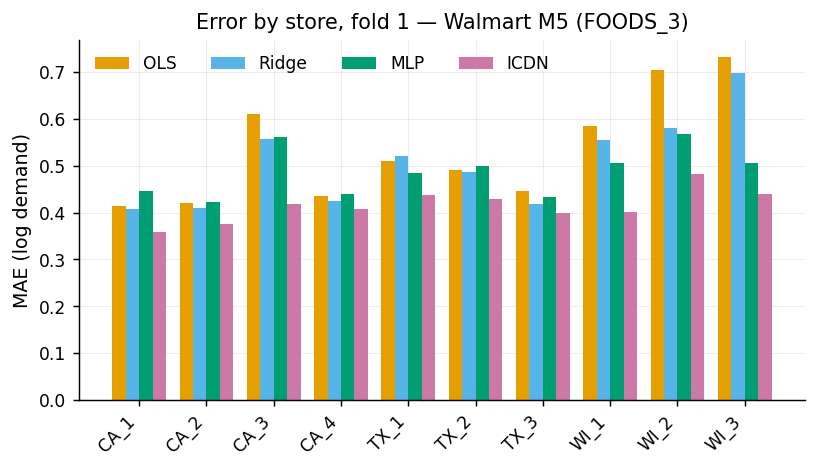

**Ten products with the largest MAE range across models (Walmart M5 (FOODS_3), fold 1)**

   product_code     ols  n_ols   ridge  n_ridge     mlp  n_mlp    icdn  \
8   FOODS_3_404  0.5244    371  0.4694      371  0.4500    412  0.3336   
12  FOODS_3_534  0.4506    435  0.4563      435  0.6160    435  0.4261   
13  FOODS_3_541  0.6387    424  0.5889      424  0.4729    424  0.4555   
15  FOODS_3_615  0.6974    352  0.6671      352  0.5430    390  0.5222   
11  FOODS_3_524  0.5345    375  0.5188      375  0.5642    421  0.3918   
3   FOODS_3_124  0.5210    385  0.4865      385  0.4759    385  0.3570   
2   FOODS_3_115  0.5898    313  0.5357      313  0.4578    390  0.4274   
0   FOODS_3_041  0.5543     91  0.5719       91  0.6138    457  0.4531   
16  FOODS_3_635  0.6338    425  0.6266      425  0.4880    425  0.4921   
7   FOODS_3_324  0.3331    321  0.3145      321  0.4230    459  0.2812   

    n_icdn mae_range  
8      412    0.1909  
12     435    0.1900  
13     424    0.1832  
15     390    0.1751  
11     421    0.1724  
3      385    0.1639  
2      390    0.1623  
0

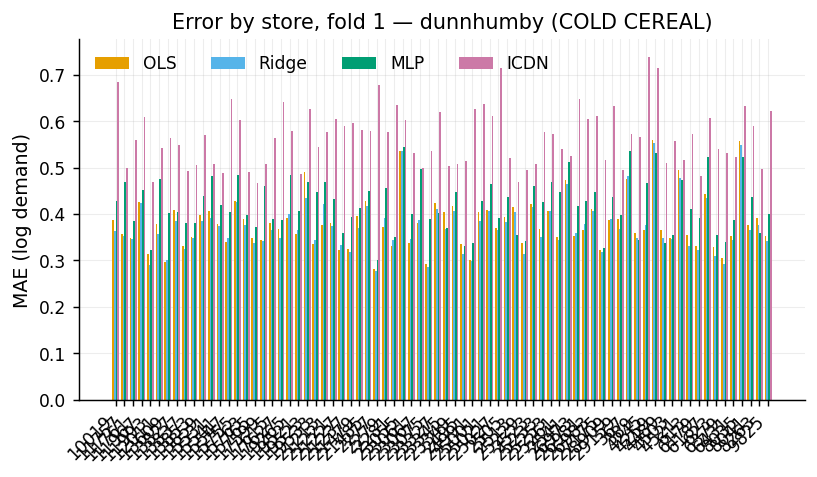

**Ten products with the largest MAE range across models (dunnhumby (COLD CEREAL), fold 1)**

   product_code     ols  n_ols   ridge  n_ridge     mlp  n_mlp    icdn  \
9    3800039118  0.3556   1971  0.3438     1971  0.4262   1971  0.6842   
6    3000006560  0.3771   1976  0.3825     1976  0.4245   1976  0.6752   
2    1111085350  0.2856   1969  0.2872     1969  0.3275   1969  0.5640   
3    1600027527  0.3713   1976  0.3522     1976  0.3661   1976  0.6278   
7    3000006610  0.4611   1973  0.4663     1973  0.5190   1973  0.6800   
8    3800031838  0.3514   1975  0.3438     1975  0.4514   1975  0.5367   
1    1111085345  0.3318   1429  0.3094     1429  0.3267   1975  0.4466   
4    1600027528  0.3547    728  0.3580      728  0.4155   1976  0.4570   
0    1111085319  0.4080   1844  0.3811     1844  0.3534   1974  0.4501   
5    1600027564  0.4856   1971  0.4841     1971  0.5789   1971  0.5368   

   n_icdn mae_range  
9    1971    0.3403  
6    1976    0.2982  
2    1969    0.2784  
3    1976    0.2756  
7    1973    0.2189  
8    1975    0.1929  
1    1975    0.1372  
4    1976

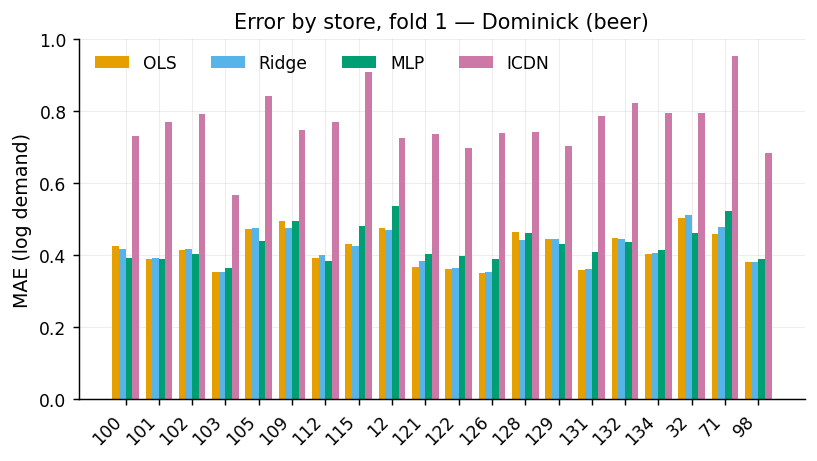

**Ten products with the largest MAE range across models (Dominick (beer), fold 1)**

    product_code     ols  n_ols   ridge  n_ridge     mlp  n_mlp    icdn  \
18    7204001113  0.5377    688  0.5376      688  0.4962    688  1.1853   
2     1820000987  0.5134    691  0.5199      691  0.5386    691  1.1989   
19    7336011751  0.5561    681  0.5654      681  0.4431    681  1.0972   
0     1820000016  0.4448    714  0.4229      714  0.4071    714  1.0258   
1     1820000834  0.4278    704  0.4318      704  0.5604    704  1.0243   
7     3410000554  0.4105    708  0.4188      708  0.4102    708  0.9389   
9     3410015505  0.4379    705  0.4298      705  0.4465    705  0.8611   
3     1820011047  0.4663    699  0.4641      699  0.5420    699  0.8760   
5     1820053168  0.4424    702  0.4422      702  0.4837    702  0.8007   
15    3410057505  0.3901    719  0.3790      719  0.3925    719  0.7032   

    n_icdn mae_range  
18     688    0.6891  
2      691    0.6856  
19     681    0.6541  
0      714    0.6187  
1      704    0.5965  
7      708    0.5286  
9      705   

In [8]:
def plot_store_mae(panel: Path, dataset: str, fold, stem: str):
    frames = []
    for model in MODEL_ORDER:
        grid = pred_cells(panel, model, fold)
        if grid.empty:
            continue
        part = error_by_group(grid, "store_code")
        part["model"] = model
        frames.append(part)
    if not frames:
        return
    df = pd.concat(frames, ignore_index=True)
    stores = sorted(df["store_code"].astype(str).unique())
    fig, ax = plt.subplots(figsize=(7.2, 3.6))
    models = [m for m in MODEL_ORDER if m in set(df["model"])]
    width = 0.8 / max(len(models), 1)
    x = np.arange(len(stores))
    for i, model in enumerate(models):
        lookup = (
            df[df["model"] == model]
            .assign(store_code=lambda x: x["store_code"].astype(str))
            .set_index("store_code")["mae"]
        )
        vals = [float(lookup.loc[s]) if s in lookup.index else np.nan for s in stores]
        ax.bar(x + (i - (len(models) - 1) / 2) * width, vals, width=width, color=COLOR[model], label=MODEL_LABEL[model])
    ax.set_xticks(x)
    ax.set_xticklabels(stores, rotation=45, ha="right")
    ax.set_ylabel("MAE (log demand)")
    ax.set_title(f"Error by store, fold {fold} — {DATASET_LABEL[dataset]}")
    ax.legend(ncol=len(models))
    savefig(fig, stem)
    plt.show()
    plt.close(fig)


def product_mae_table(panel: Path, fold) -> pd.DataFrame:
    frames = []
    for model in MODEL_ORDER:
        grid = pred_cells(panel, model, fold)
        if grid.empty:
            continue
        part = error_by_group(grid, "product_code")
        part = part.rename(columns={"mae": model})
        frames.append(part[["product_code", model, "n"]].rename(columns={"n": f"n_{model}"}))
    if not frames:
        return pd.DataFrame()
    out = frames[0]
    for part in frames[1:]:
        out = out.merge(part, on="product_code", how="outer")
    metric_cols = [m for m in MODEL_ORDER if m in out.columns]
    out["mae_range"] = out[metric_cols].max(axis=1) - out[metric_cols].min(axis=1)
    return out.sort_values("mae_range", ascending=False)


for key, panel in PANELS.items():
    kfold = load_all("kfold.csv", panel)
    folds = sorted(present_folds(kfold), key=lambda x: int(x) if str(x).isdigit() else 0)
    if not folds:
        continue
    fold = folds[0]
    plot_store_mae(panel, key, fold, f"{key}_fold{fold}_mae_store")
    prod = product_mae_table(panel, fold)
    if len(prod):
        show_table(prod.head(10), f"Ten products with the largest MAE range across models ({DATASET_LABEL[key]}, fold {fold})")


`matched_prediction_metrics.csv` compares model pairs on the same observations. ΔMAE = MAE_a - MAE_b; negative favours a. Fold-level ΔMAE is a point contrast only — Section 3 puts a CI on the pooled ICDN–MLP difference.

A **week-block bootstrap** (block size `BLOCK_SIZE`, B = `N_BOOT_PRED_INFER` draws, no retraining) yields a percentile 95% CI for ΔMAE, and the same draws for ΔRMSE and ΔR2.

The pre-specified non-inferiority margin is delta = `PRED_NI_MARGIN` log-demand MAE units (a design constant, not chosen after seeing the CI). Classification:

- **ICDN superior** if the CI upper bound is < 0;
- **MLP superior** if the CI lower bound is > 0;
- **ICDN non-inferior** if the upper bound is < delta but the interval still covers 0;
- **indistinguishable** otherwise.

Also reported: the share of store–product series with lower MAE under ICDN, the same share weighted by cell count, and the share of cells with smaller absolute error..


**Table 5. Paired ICDN−MLP predictive inference (week-block bootstrap)**

     dataset    split  n_cells  n_series  n_weeks  n_blocks mae_icdn mae_mlp  \
0    walmart    outer    22782       200      139         7   0.4814  0.5266   
1    walmart  holdout     8453       200       56         3   0.5176  0.5736   
2  dunnhumby    outer    55983       760       78         4   0.4994  0.4506   
3  dunnhumby  holdout    21059       760       32         2   0.5258  0.5623   
4   dominick    outer    43285       400      110         6   0.6166  0.4483   
5   dominick  holdout    17215       400       44         3   0.5023  0.4353   

  delta_mae delta_mae_ci_lo  ... delta_rmse_ci_lo delta_rmse_ci_hi delta_r2  \
0   -0.0453         -0.0820  ...          -0.1022           0.0034   0.0482   
1   -0.0560         -0.1081  ...          -0.1338          -0.0181   0.0666   
2    0.0487         -0.0289  ...          -0.0346           0.1413  -0.0851   
3   -0.0365         -0.0596  ...          -0.0644          -0.0559   0.0894   
4    0.1683          0.0840  ...           0

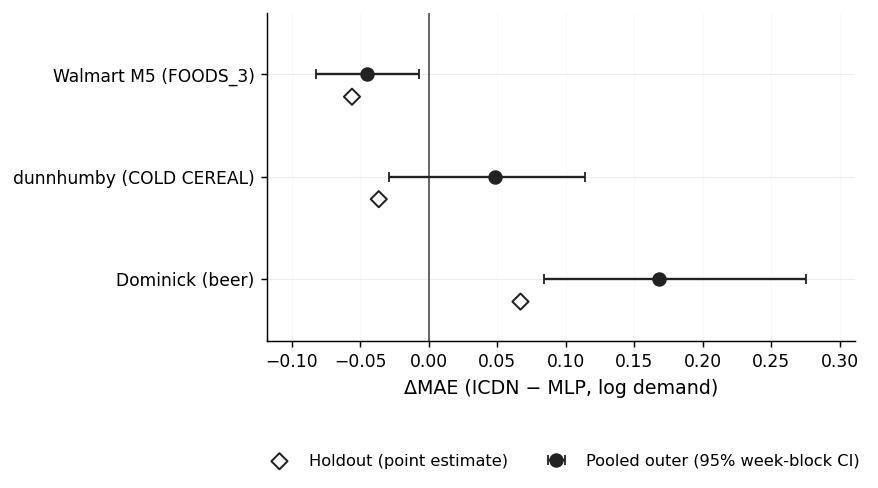

**Store–product series: median ΔMAE and share with ICDN MAE below MLP**

     dataset    split  n_series median_delta_mae share_icdn_better
0   dominick  holdout       400           0.0449            0.3150
1   dominick    outer       400           0.1458            0.0850
2  dunnhumby  holdout       760          -0.0400            0.5908
3  dunnhumby    outer       760           0.0545            0.2842
4    walmart  holdout       200          -0.0180            0.5600
5    walmart    outer       200          -0.0300            0.6600


In [11]:
pred_inf = pd.concat(
    [read_csv(p / "paired_predictive_inference.csv") for p in PANELS.values()],
    ignore_index=True,
)
pred_series = pd.concat(
    [read_csv(p / "paired_predictive_series.csv") for p in PANELS.values()],
    ignore_index=True,
)
if pred_inf.empty:
    print("paired_predictive_inference.csv missing — rebuild_all writes it from pred_cells.")
else:
    show = pred_inf.copy()
    show["conclusion_label"] = show["conclusion"].map(CONCLUSION_LABEL)
    cols = [
        "dataset", "split", "n_cells", "n_series", "n_weeks", "n_blocks",
        "mae_icdn", "mae_mlp", "delta_mae", "delta_mae_ci_lo", "delta_mae_ci_hi",
        "delta_rmse", "delta_rmse_ci_lo", "delta_rmse_ci_hi",
        "delta_r2", "delta_r2_ci_lo", "delta_r2_ci_hi",
        "share_series_icdn_better", "share_series_icdn_better_weighted",
        "share_cells_icdn_better", "ni_margin", "conclusion_label",
    ]
    show_table(show[[c for c in cols if c in show.columns]], "Table 5. Paired ICDN−MLP predictive inference (week-block bootstrap)")

ORDER = ["walmart", "dunnhumby", "dominick"]


def plot_delta_mae_ci(inf: pd.DataFrame, stem: str):
    if inf.empty:
        return
    outer = inf.loc[inf["split"].eq("outer")].set_index("dataset")
    hold = inf.loc[inf["split"].eq("holdout")].set_index("dataset")
    names = [d for d in ORDER if d in outer.index]
    if not names:
        return
    y = np.arange(len(names), dtype=float)
    o = outer.loc[names]
    lo = o["delta_mae"] - o["delta_mae_ci_lo"]
    hi = o["delta_mae_ci_hi"] - o["delta_mae"]

    fig, ax = plt.subplots(figsize=(6.8, 0.85 * len(names) + 1.5))
    ax.errorbar(
        o["delta_mae"], y, xerr=np.vstack([lo, hi]),
        fmt="o", color="#222222", capsize=3, ms=7, lw=1.3, zorder=3,
        label="Pooled outer (95% week-block CI)",
    )
    if len(hold):
        h = hold.reindex(names)
        ax.scatter(
            h["delta_mae"], y + 0.22, marker="D", facecolors="none",
            edgecolors="#222222", s=40, linewidths=1.1, zorder=4,
            label="Holdout (point estimate)",
        )
    ax.axvline(0, color="0.35", lw=1.0, zorder=1)
    ax.set_yticks(y)
    ax.set_yticklabels([DATASET_LABEL.get(d, d) for d in names])
    ax.set_ylim(len(names) - 0.4, -0.6)
    ax.margins(x=0.10)
    ax.grid(axis="x", color="0.9", lw=0.6)
    ax.set_axisbelow(True)
    ax.set_xlabel("ΔMAE (ICDN − MLP, log demand)")
    xmin, xmax = ax.get_xlim()
    ax.legend(frameon=False, fontsize=9, ncol=2,
              loc="upper center", bbox_to_anchor=(0.5, -0.30))
    fig.tight_layout()
    savefig(fig, stem)
    plt.show()
    plt.close(fig)

if len(pred_inf):
    plot_delta_mae_ci(pred_inf, "paired_delta_mae_ci")
if len(pred_series):
    overview = (
        pred_series.groupby(["dataset", "split"], as_index=False)
        .agg(
            n_series=("product_code", "size"),
            median_delta_mae=("delta_mae", "median"),
            share_icdn_better=("icdn_better", "mean"),
        )
    )
    show_table(overview, "Store–product series: median ΔMAE and share with ICDN MAE below MLP")


## 4. Pairwise equations (OLS / Ridge)

`fold{k}_pred_ij.csv` stores `y_hat_ijst` from each equation. The cell prediction is `y_hat_ist = mean_j y_hat_ijst`. This section audits partners per cell and that the aggregate matches `pred_cells`.


In [ ]:
def audit_pred_ij(panel: Path, model: str, fold) -> pd.DataFrame | None:
    path = panel / model / (f"fold{fold}_pred_ij.csv" if str(fold) != "holdout" else "holdout_pred_ij.csv")
    cells_path = panel / model / (f"fold{fold}_pred_cells.csv" if str(fold) != "holdout" else "holdout_pred_cells.csv")
    ij = read_csv(path)
    cells = read_csv(cells_path)
    if ij.empty or cells.empty:
        return None
    agg = (
        ij.groupby(["store_code", "product_i", "week_id"], as_index=False)
        .agg(y_true=("y_true", "first"), y_pred_mean=("y_pred", "mean"), n_partners=("product_j", "nunique"), n_eq=("product_j", "size"))
        .rename(columns={"product_i": "product_code"})
    )
    merged = cells.merge(agg, on=["store_code", "product_code", "week_id"], how="inner", suffixes=("", "_ij"))
    merged["abs_gap"] = (merged["y_pred"] - merged["y_pred_mean"]).abs()
    return pd.Series({
        "dataset": merged["dataset"].iloc[0] if "dataset" in merged.columns else panel.parent.name,
        "model": model,
        "fold": fold,
        "n_eq_rows": len(ij),
        "n_cells_with_eq": len(agg),
        "n_partners_mean": float(agg["n_partners"].mean()),
        "n_partners_min": int(agg["n_partners"].min()),
        "n_partners_max": int(agg["n_partners"].max()),
        "max_abs_gap_vs_pred_cells": float(merged["abs_gap"].max()) if len(merged) else np.nan,
        "mae_from_ij": float(np.mean(np.abs(agg["y_true"] - agg["y_pred_mean"]))),
    }).to_frame().T


audits = []
for key, panel in PANELS.items():
    kfold = load_all("kfold.csv", panel)
    folds = sorted(present_folds(kfold), key=lambda x: int(x) if str(x).isdigit() else 0)
    for model in LINEAR_MODELS:
        for fold in folds:
            rec = audit_pred_ij(panel, model, fold)
            if rec is not None:
                audits.append(rec)
if audits:
    show_table(pd.concat(audits, ignore_index=True), "Table 6. Pairwise aggregate y_hat_ist = mean_j y_hat_ijst")
else:
    print("no pred_ij files")


**Table 6. Pairwise aggregate $\widehat y_{ist}=\mathrm{mean}_j\widehat y_{ijst}$**

      dataset  model fold n_eq_rows n_cells_with_eq n_partners_mean  \
0     walmart    ols    1     93754            6941       13.507276   
1     walmart    ols    2     94938            6988       13.585861   
2     walmart    ols    3     90314            6893       13.102278   
3     walmart  ridge    1     93754            6941       13.507276   
4     walmart  ridge    2     94938            6988       13.585861   
5     walmart  ridge    3     90314            6893       13.102278   
6   dunnhumby    ols    1    155204           17812        8.713452   
7   dunnhumby    ols    2    166595           19016         8.76078   
8   dunnhumby    ols    3    115545           15801        7.312512   
9   dunnhumby  ridge    1    155204           17812        8.713452   
10  dunnhumby  ridge    2    166595           19016         8.76078   
11  dunnhumby  ridge    3    115545           15801        7.312512   
12   dominick    ols    1    248561           14188       17.519101   
13   d

## 5. Out-of-sample elasticities

Each row of `kfold_series.csv` is a series (store, i, j, kind) in an outer fold. Networks average the weekly elasticity in the fold; OLS/Ridge store the fitted beta of the equation (and `kind=own_eq` in addition to the product mean).

Economic regularity: own-price negative; cross-price in a bounded band. OLS produces extreme tails — percentiles and shares are more informative than the mean.

Boxplots clip to [-5, 5] (own) and [-2, 2] (cross) for readability. Table 8 reports how many series those windows drop, with the unclipped min and max.


In [10]:
OWN_COLS = [
    "dataset", "model", "fold","kind", "n", "mean", "median", "std", "iqr",
    "q025", "q975", "min", "max", "share_in_minus5_0", "share_positive", "share_abs_gt5",
]
CROSS_COLS = [
    "dataset", "model", "fold", "n", "mean", "median", "std", "iqr",
    "q025", "q975", "share_positive", "share_negative", "share_abs_le1", "share_abs_gt1", "share_abs_gt3",
]

series_parts = []
for p in PANELS.values():
    df = load_all("kfold_series.csv", p)
    if len(df):
        series_parts.append(df)
all_series = pd.concat(series_parts, ignore_index=True) if series_parts else pd.DataFrame()
if "outer_fold" not in all_series.columns and "fold" in all_series.columns:
    all_series["outer_fold"] = all_series["fold"]

elast_tab = elasticity_distribution(all_series)
if elast_tab.empty:
    print("no kfold_series.csv")
else:
    own = elast_tab[elast_tab["kind"].astype(str).isin(["own", "own_eq"])]
    cross = elast_tab[elast_tab["kind"].astype(str) == "cross"]
    if len(own):
        show_table(own[[c for c in OWN_COLS if c in own.columns]].sort_values(["dataset", "fold", "kind", "model"]),
                   "Table 7a. Own-price OOS distribution (native set)")
    if len(cross):
        show_table(cross[[c for c in CROSS_COLS if c in cross.columns]].sort_values(["dataset", "fold", "model"]),
                   "Table 7b. Cross-price OOS distribution (native set)")


**Table 7a. Own-price OOS distribution (native set)**

      dataset  model  fold    kind     n     mean   median      std     iqr  \
1    dominick   icdn     1     own   400  -1.7039  -1.6866   0.0736  0.1175   
7    dominick    mlp     1     own   400  -0.9525  -0.9713   0.5587  0.6990   
13   dominick    ols     1     own   400  -4.6362  -4.7733   2.1362  2.7168   
22   dominick  ridge     1     own   400  -3.6763  -3.5204   2.0096  2.6834   
14   dominick    ols     1  own_eq  7113  -4.6342  -4.7543   2.2322  2.7717   
23   dominick  ridge     1  own_eq  7113  -3.6685  -3.4879   2.1189  2.9054   
3    dominick   icdn     2     own   400  -2.4843  -2.4289   0.1884  0.2635   
9    dominick    mlp     2     own   400  -0.8232  -0.9475   0.4803  0.7465   
16   dominick    ols     2     own   400  -4.7676  -4.7342   1.8500  2.2996   
25   dominick  ridge     2     own   400  -3.9323  -3.8126   1.8019  2.3249   
17   dominick    ols     2  own_eq  7099  -4.7712  -4.7375   1.9247  2.4104   
26   dominick  ridge     2  own_eq  7099  -3.9315  -

**Table 7b. Cross-price OOS distribution (native set)**

      dataset  model  fold     n     mean   median      std     iqr      q025  \
0    dominick   icdn     1  1600   0.8916   0.9001   0.2641  0.3491    0.4122   
6    dominick    mlp     1  7600  -0.0430  -0.0034   0.3011  0.2869   -0.9635   
12   dominick    ols     1  7113   0.2727   0.1431   1.4460  1.2022   -2.2190   
21   dominick  ridge     1  7113   0.0131  -0.0122   1.1572  0.9052   -2.2630   
2    dominick   icdn     2   800   1.0951   1.0674   0.2404  0.3266    0.6128   
8    dominick    mlp     2  7600  -0.0351   0.0036   0.2850  0.2694   -0.9466   
15   dominick    ols     2  7099   0.1633   0.1601   1.3044  1.0094   -2.7911   
24   dominick  ridge     2  7099   0.0035   0.0491   1.1465  0.8547   -2.6867   
4    dominick   icdn     3  1600   0.3055   0.3080   0.1528  0.2057   -0.0161   
10   dominick    mlp     3  7600  -0.0384  -0.0020   0.3268  0.2816   -1.0521   
18   dominick    ols     3  7151   0.0654   0.0880   1.5652  1.0203   -3.2529   
27   dominick  ridge     3  

**Table 8. Boxplot clipping audit (n_clipped / share_clipped vs unclipped min–max)**

      dataset  model   kind      n   min_full  max_full  clip_lo clip_hi  \
0    dominick   icdn  cross   4000    -0.2180    2.2181  -1.0000  1.0000   
2    dominick    mlp  cross  22800    -1.9721    0.7819  -1.0000  1.0000   
4    dominick    ols  cross  21363   -13.4501   13.6588  -1.0000  1.0000   
6    dominick  ridge  cross  21363   -13.4375   13.0554  -1.0000  1.0000   
1    dominick   icdn    own   1200    -4.1020   -1.5912  -5.0000  0.0000   
3    dominick    mlp    own   1200    -2.6856    0.2631  -5.0000  0.0000   
5    dominick    ols    own   1200   -10.3519    5.3074  -5.0000  0.0000   
7    dominick  ridge    own   1200    -9.6639    3.7877  -5.0000  0.0000   
8   dunnhumby   icdn  cross   7564    -4.7368    4.5764  -2.0000  2.0000   
10  dunnhumby    mlp  cross  20400    -1.3922    1.0083  -2.0000  2.0000   
12  dunnhumby    ols  cross  18739   -11.0501    4.5334  -2.0000  2.0000   
14  dunnhumby  ridge  cross  18739    -8.1740    3.8893  -2.0000  2.0000   
9   dunnhumb

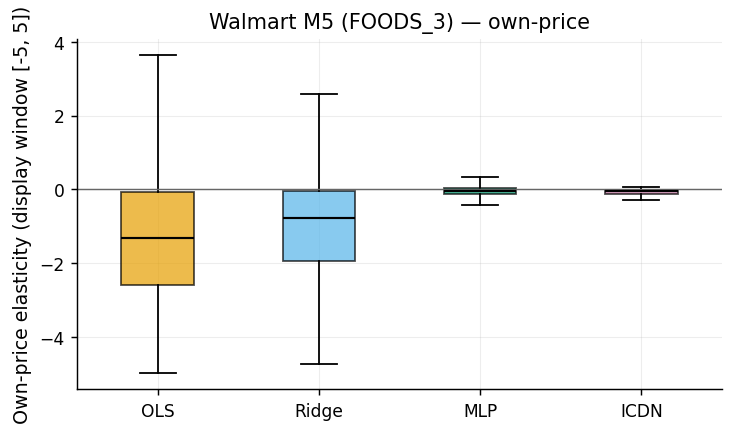

  figure /home/thebigmonster/Github/nn-elasticity-additional-work/notebooks/figures/walmart_cross_box.pdf


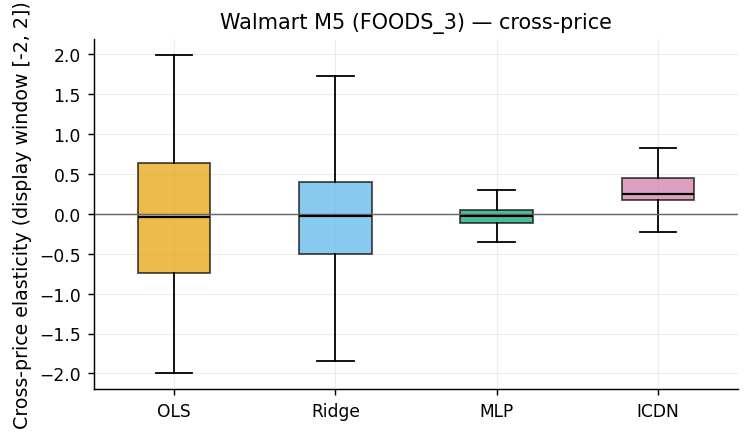

  figure /home/thebigmonster/Github/nn-elasticity-additional-work/notebooks/figures/dunnhumby_own_box.pdf


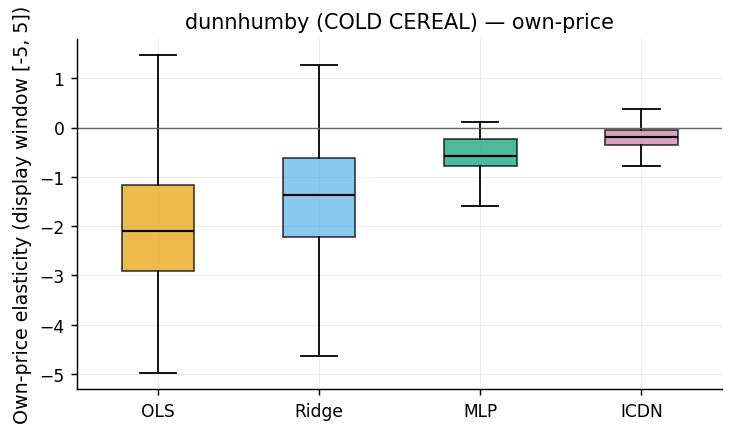

  figure /home/thebigmonster/Github/nn-elasticity-additional-work/notebooks/figures/dunnhumby_cross_box.pdf


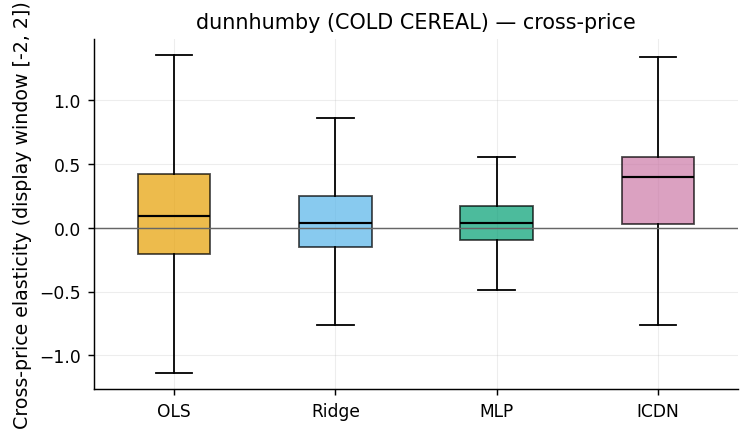

  figure /home/thebigmonster/Github/nn-elasticity-additional-work/notebooks/figures/dominick_own_box.pdf


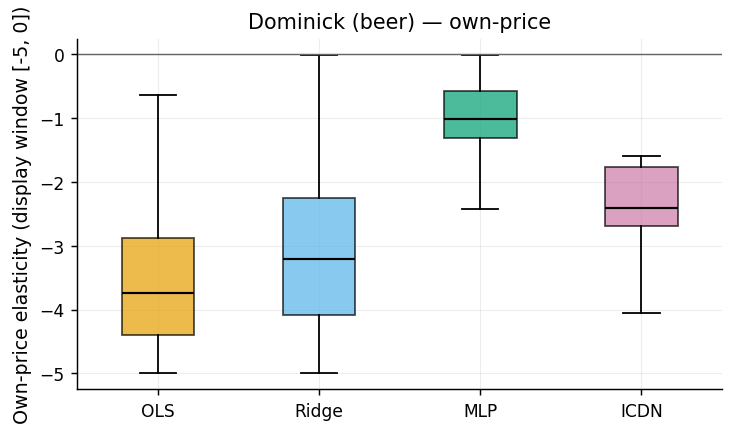

  figure /home/thebigmonster/Github/nn-elasticity-additional-work/notebooks/figures/dominick_cross_box.pdf


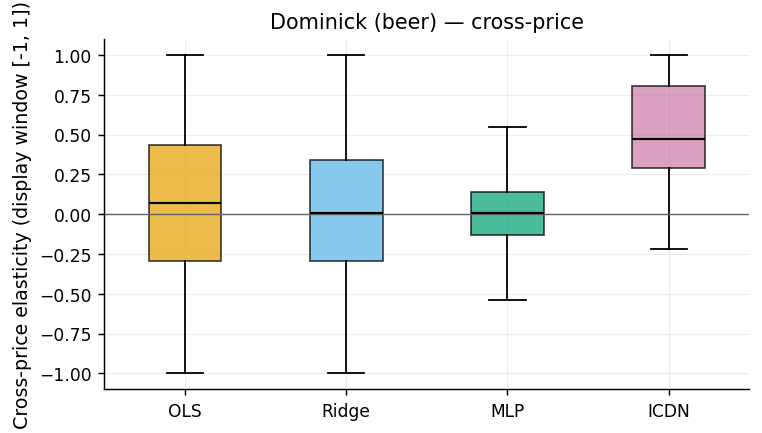

In [11]:
def plot_elasticity_box(series: pd.DataFrame, dataset: str, kind: str, stem: str, clip=None):
    df = series[(series["dataset"] == dataset) & (series["kind"] == kind)].copy()
    if df.empty:
        return
    df["elasticity"] = pd.to_numeric(df["elasticity"], errors="coerce")
    plotted = df
    if clip is not None:
        plotted = df[(df["elasticity"] >= clip[0]) & (df["elasticity"] <= clip[1])]
    fig, ax = plt.subplots(figsize=(6.4, 3.5))
    data, labels, colors = [], [], []
    for model in MODEL_ORDER:
        part = plotted[plotted["model"] == model]["elasticity"].dropna()
        if part.empty:
            continue
        data.append(part.to_numpy())
        labels.append(MODEL_LABEL[model])
        colors.append(COLOR[model])
    if not data:
        return
    bp = ax.boxplot(data, patch_artist=True, showfliers=False, medianprops={"color": "black", "linewidth": 1.2})
    ax.set_xticks(range(1, len(labels) + 1))
    ax.set_xticklabels(labels)
    for patch, c in zip(bp["boxes"], colors):
        patch.set_facecolor(c)
        patch.set_alpha(0.7)
    ax.axhline(0, color="0.4", lw=0.8)
    ylab = KIND_LABEL.get(kind, kind).capitalize() + " elasticity"
    if clip is not None:
        ylab += f" (display window [{clip[0]:.0f}, {clip[1]:.0f}])"
    ax.set_ylabel(ylab)
    ax.set_title(f"{DATASET_LABEL[dataset]} — {KIND_LABEL.get(kind, kind)}")
    savefig(fig, stem)
    plt.show()
    plt.close(fig)


if len(all_series):
    clip_parts = []
    for ds, sub in all_series[all_series["kind"].isin(["own", "cross"])].groupby("dataset"):
        clip_parts.append(elasticity_clip_diagnostics(sub, clips_for(ds)))
    clip_tab = pd.concat(clip_parts, ignore_index=True) if clip_parts else pd.DataFrame()
    if len(clip_tab):
        show_table(
            clip_tab.sort_values(["dataset", "kind", "model"]),
            "Table 8. Boxplot clipping audit (n_clipped / share_clipped vs unclipped min–max)",
        )
    for key in PANELS:
        sub = all_series[all_series["dataset"] == key]
        if sub.empty:
            continue
        clip = clips_for(key)
        plot_elasticity_box(all_series, key, "own", f"{key}_own_box", clip=clip["own"])
        plot_elasticity_box(all_series, key, "cross", f"{key}_cross_box", clip=clip["cross"])


## 6. Temporal stability (`kfold_series_stats`)

`fold_sd` is the SD of the **same** series across outer folds. `fold_range` is max - min. `sign_stable=1` if the sign does not flip (zeros ignored). `dominant_sign_share` is the majority-sign fraction.

The headline cross-price reproducibility result is not that native set. An edge must appear in all `N_FOLDS` outer folds **and** on the same fold IDs in both models of the comparison (ICDN∩MLP, ICDN∩Ridge, ICDN∩OLS). That is `edge_matched_kfold_sd.csv` (`stability_set=all_folds`).

Coverage is separate in `edge_matched_kfold_coverage.csv`: presence frequency, edges in every fold, edges in at least two folds, and `n_edges_stable` (the full intersection).


In [12]:
stats_parts = []
for p in PANELS.values():
    df = load_all("kfold_series_stats.csv", p)
    if len(df):
        stats_parts.append(df)
all_stats = pd.concat(stats_parts, ignore_index=True) if stats_parts else pd.DataFrame()


def stats_overview(stats: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for (dataset, model, kind), part in stats.groupby(["dataset", "model", "kind"]):
        sd = pd.to_numeric(part["fold_sd"], errors="coerce")
        rng = pd.to_numeric(part.get("fold_range"), errors="coerce") if "fold_range" in part.columns else pd.Series(dtype=float)
        rows.append({
            "dataset": dataset, "model": model, "kind": kind,
            "n_series": len(part),
            "median_n_folds": float(part["n_folds"].median()) if "n_folds" in part.columns else np.nan,
            "median_fold_sd": float(sd.median()),
            "median_fold_range": float(rng.median()) if len(rng) else np.nan,
            "share_sign_stable": float(pd.to_numeric(part["sign_stable"], errors="coerce").mean()) if "sign_stable" in part.columns else np.nan,
            "median_dominant_sign_share": float(pd.to_numeric(part.get("dominant_sign_share"), errors="coerce").median()) if "dominant_sign_share" in part.columns else np.nan,
        })
    out = pd.DataFrame(rows)
    out["model"] = pd.Categorical(out["model"], MODEL_ORDER, ordered=True)
    return out.sort_values(["dataset", "kind", "model"])


if len(all_stats):
    show_table(stats_overview(all_stats), "Table 9. Temporal stability by model (native set)")

cov_parts, sd_parts = [], []
for p in PANELS.values():
    cov_parts.append(read_csv(p / "edge_matched_kfold_coverage.csv"))
    sd_parts.append(read_csv(p / "edge_matched_kfold_sd.csv"))
edge_cov = pd.concat([x for x in cov_parts if len(x)], ignore_index=True) if any(len(x) for x in cov_parts) else pd.DataFrame()
edge_sd = pd.concat([x for x in sd_parts if len(x)], ignore_index=True) if any(len(x) for x in sd_parts) else pd.DataFrame()

if edge_cov.empty:
    print("edge_matched_kfold_coverage.csv missing.")
else:
    show_table(edge_cov.sort_values(["dataset", "eval", "model"]), "Table 9b. Edge coverage across folds")

if edge_sd.empty:
    print("edge_matched_kfold_sd.csv empty (no edges in all folds with the same IDs).")
else:
    show_table(edge_sd.sort_values(["dataset", "eval", "model"]), "Table 9c. fold_sd on the complete set (n_folds = N_FOLDS, same IDs)")


**Table 9. Temporal stability by model (native set)**

      dataset  model    kind  n_series median_n_folds median_fold_sd  \
4    dominick    ols   cross      7197         3.0000         0.2723   
7    dominick  ridge   cross      7197         3.0000         0.2540   
2    dominick    mlp   cross      7600         3.0000         0.1050   
0    dominick   icdn   cross      3040         1.0000         0.4246   
5    dominick    ols     own       400         3.0000         0.4750   
8    dominick  ridge     own       400         3.0000         0.6600   
3    dominick    mlp     own       400         3.0000         0.1691   
1    dominick   icdn     own       400         3.0000         0.5341   
6    dominick    ols  own_eq      7197         3.0000         0.4958   
9    dominick  ridge  own_eq      7197         3.0000         0.7309   
14  dunnhumby    ols   cross      6470         3.0000         0.1612   
17  dunnhumby  ridge   cross      6470         3.0000         0.1241   
12  dunnhumby    mlp   cross      6840         3.0000         0.

**Table 9b. Edge coverage across folds**

      dataset                eval  model   kind  n_protocol_folds  n_edges  \
20   dominick    matched_icdn_mlp   icdn  cross                 3     3040   
21   dominick    matched_icdn_mlp    mlp  cross                 3     3040   
22   dominick    matched_icdn_ols   icdn  cross                 3     2753   
23   dominick    matched_icdn_ols    ols  cross                 3     2753   
24   dominick  matched_icdn_ridge   icdn  cross                 3     2753   
25   dominick  matched_icdn_ridge  ridge  cross                 3     2753   
26   dominick              native   icdn  cross                 3     3040   
27   dominick              native    mlp  cross                 3     7600   
28   dominick              native    ols  cross                 3     7197   
29   dominick              native  ridge  cross                 3     7197   
10  dunnhumby    matched_icdn_mlp   icdn  cross                 3     3572   
11  dunnhumby    matched_icdn_mlp    mlp  cross                 

**Table 9c. fold_sd on the complete set (n_folds = N_FOLDS, same IDs)**

      dataset                eval  model   kind  n_series  n_series_sd  \
20   dominick    matched_icdn_mlp   icdn  cross       200          200   
21   dominick    matched_icdn_mlp    mlp  cross       200          200   
22   dominick    matched_icdn_ols   icdn  cross       197          197   
23   dominick    matched_icdn_ols    ols  cross       197          197   
24   dominick  matched_icdn_ridge   icdn  cross       197          197   
25   dominick  matched_icdn_ridge  ridge  cross       197          197   
26   dominick              native   icdn  cross       200          200   
27   dominick              native    mlp  cross      7600         7600   
28   dominick              native    ols  cross      7059         7059   
29   dominick              native  ridge  cross      7059         7059   
10  dunnhumby    matched_icdn_mlp   icdn  cross      1514         1514   
11  dunnhumby    matched_icdn_mlp    mlp  cross      1514         1514   
12  dunnhumby    matched_icdn_ols   ic

## 7. Weekly elasticities (MLP / ICDN)

`fold{k}_elasticities_long.csv` unpacks the fold mean into weeks, with `observed_i` and `observed_j`. `share_obs_both` is P(observed_i and observed_j), not the product of the two marginal shares.

If the file is missing, skip this section and re-run MLP/ICDN.


**Table 10. Within-fold weekly heterogeneity (MLP/ICDN)**

      dataset model  fold   kind  n_rows share_positive      p05      p50  \
0    dominick  icdn     1  cross   56231         1.0000   0.3859   0.8758   
1    dominick  icdn     1    own   14188         0.0000  -1.9528  -1.6688   
2    dominick  icdn     2  cross   28145         1.0000   0.6582   1.0272   
3    dominick  icdn     2    own   14246         0.0000  -2.8756  -2.4363   
4    dominick  icdn     3  cross   58062         0.9244  -0.0474   0.3097   
5    dominick  icdn     3    own   14851         0.0000  -3.6234  -2.7680   
6    dominick   mlp     1  cross  265660         0.4914  -0.6658  -0.0054   
7    dominick   mlp     1    own   14188         0.0144  -2.0039  -0.9301   
8    dominick   mlp     2  cross  267818         0.4982  -0.6150  -0.0011   
9    dominick   mlp     2    own   14246         0.0344  -1.6719  -0.8942   
10   dominick   mlp     3  cross  275716         0.4972  -0.6713  -0.0016   
11   dominick   mlp     3    own   14851         0.0108  -2.0876  -1.1653   

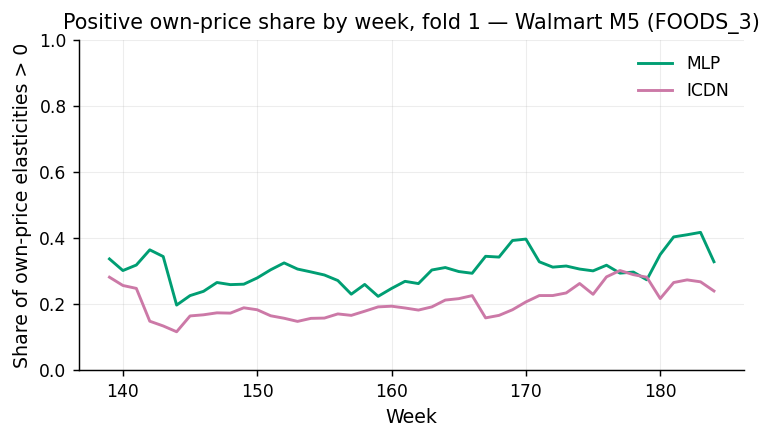

  figure /home/thebigmonster/Github/nn-elasticity-additional-work/notebooks/figures/dunnhumby_own_positive_week.pdf


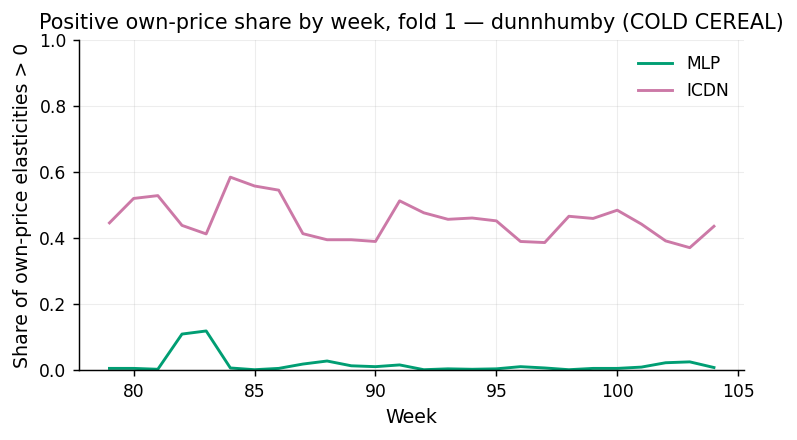

  figure /home/thebigmonster/Github/nn-elasticity-additional-work/notebooks/figures/dominick_own_positive_week.pdf


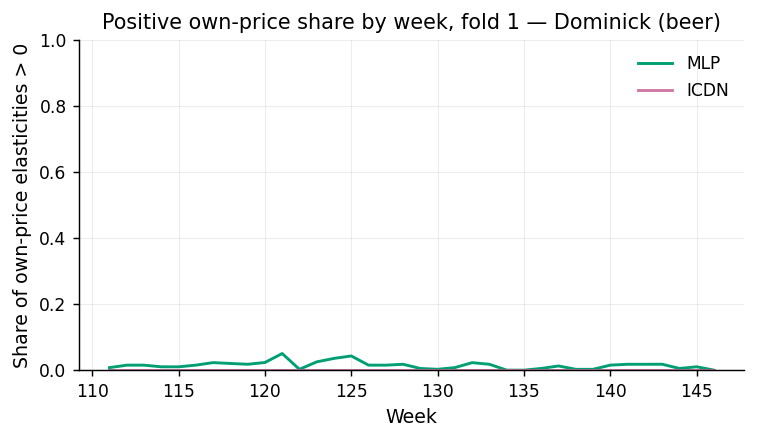

In [13]:
def load_long(panel: Path) -> pd.DataFrame:
    parts = []
    for model in NEURAL_MODELS:
        for path in sorted((panel / model).glob("fold*_elasticities_long.csv")):
            parts.append(read_csv(path))
    return pd.concat(parts, ignore_index=True) if parts else pd.DataFrame()


def long_overview(long: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for (dataset, model, fold, kind), part in long.groupby(["dataset", "model", "outer_fold", "kind"]):
        e = pd.to_numeric(part["elasticity"], errors="coerce").dropna()
        rows.append({
            "dataset": dataset, "model": model, "fold": fold, "kind": kind,
            "n_rows": int(len(e)),
            "share_positive": float((e > 0).mean()),
            "p05": float(e.quantile(0.05)),
            "p50": float(e.quantile(0.50)),
            "p95": float(e.quantile(0.95)),
            "p995": float(e.quantile(0.995)),
            "share_obs_both": share_obs_both(part),
        })
    return pd.DataFrame(rows)


long_parts = [load_long(p) for p in PANELS.values()]
all_long = pd.concat([x for x in long_parts if len(x)], ignore_index=True) if any(len(x) for x in long_parts) else pd.DataFrame()
if all_long.empty:
    print("No fold*_elasticities_long.csv. Produced on the next MLP/ICDN run.")
else:
    show_table(long_overview(all_long), "Table 10. Within-fold weekly heterogeneity (MLP/ICDN)")

    def plot_own_share_week(long: pd.DataFrame, dataset: str, fold, stem: str):
        df = long[(long["dataset"] == dataset) & (long["outer_fold"].astype(str) == str(fold)) & (long["kind"] == "own")].copy()
        if df.empty:
            return
        fig, ax = plt.subplots(figsize=(6.6, 3.3))
        for model in NEURAL_MODELS:
            part = df[df["model"] == model]
            if part.empty:
                continue
            g = part.groupby("week_id")["elasticity"].apply(lambda s: float((s > 0).mean()))
            ax.plot(g.index, g.values, color=COLOR[model], label=MODEL_LABEL[model], lw=1.6)
        ax.set_xlabel("Week")
        ax.set_ylabel("Share of own-price elasticities > 0")
        ax.set_ylim(0, 1)
        ax.set_title(f"Positive own-price share by week, fold {fold} — {DATASET_LABEL[dataset]}")
        ax.legend()
        savefig(fig, stem)
        plt.show()
        plt.close(fig)

    for key, panel in PANELS.items():
        kfold = load_all("kfold.csv", panel)
        folds = sorted(present_folds(kfold), key=lambda x: int(x) if str(x).isdigit() else 0)
        if folds:
            plot_own_share_week(all_long, key, folds[0], f"{key}_own_positive_week")


## 8. Matched-edge elasticities

`matched_elasticity_series.csv` aligns ICDN with MLP, Ridge, and OLS on common keys (store, i, j, kind). Sign agreement and absolute difference do not mix distinct neighbourhoods. Protocol `edge_matched_*.csv` tables remain the mean summary; here the pair cloud is visible.


**Table 11. Matched-edge agreement (ICDN vs MLP / Ridge / OLS)**

     dataset     fold model_a model_b   kind  n_common share_same_sign  \
0   dominick        1    icdn     mlp  cross      1600          0.4888   
2   dominick        1    icdn     ols  cross      1439          0.5601   
4   dominick        1    icdn   ridge  cross      1439          0.4802   
1   dominick        1    icdn     mlp    own       400          0.9900   
3   dominick        1    icdn     ols    own       400          0.9700   
..       ...      ...     ...     ...    ...       ...             ...   
68   walmart  holdout    icdn     ols  cross       280          0.5679   
70   walmart  holdout    icdn   ridge  cross       280          0.6000   
67   walmart  holdout    icdn     mlp    own       200          0.6000   
69   walmart  holdout    icdn     ols    own       191          0.7016   
71   walmart  holdout    icdn   ridge    own       191          0.6859   

   median_abs_diff   mean_a   mean_b  
0           0.9140   0.8916  -0.0709  
2           0.9468   0.8880   0.2

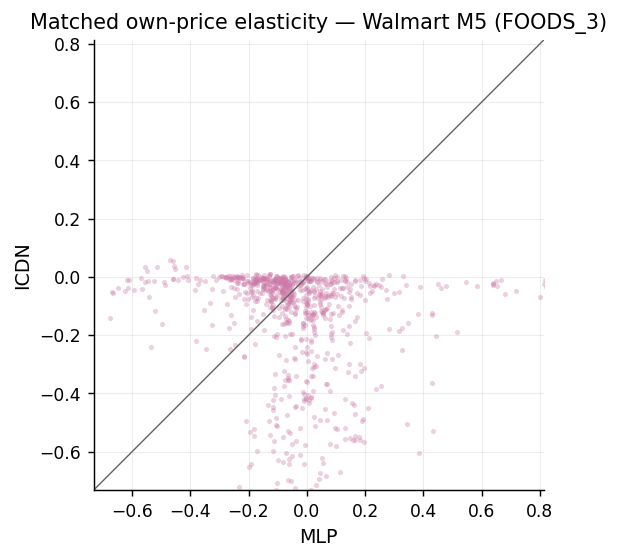

  figure /home/thebigmonster/Github/nn-elasticity-additional-work/notebooks/figures/walmart_matched_cross_scatter.pdf


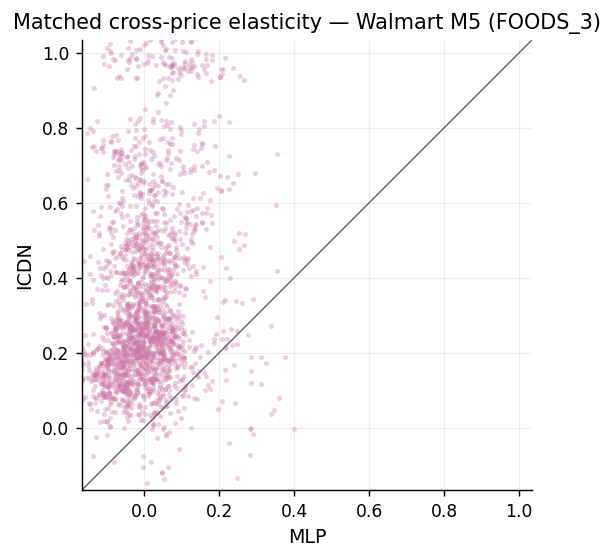

  figure /home/thebigmonster/Github/nn-elasticity-additional-work/notebooks/figures/dunnhumby_matched_own_scatter.pdf


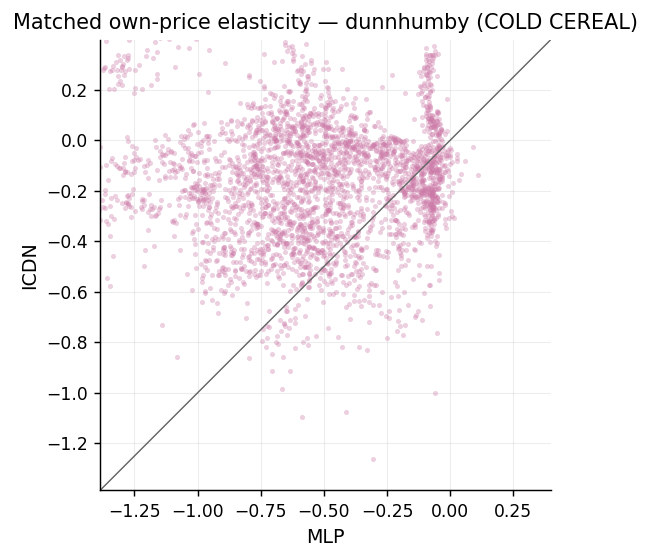

  figure /home/thebigmonster/Github/nn-elasticity-additional-work/notebooks/figures/dunnhumby_matched_cross_scatter.pdf


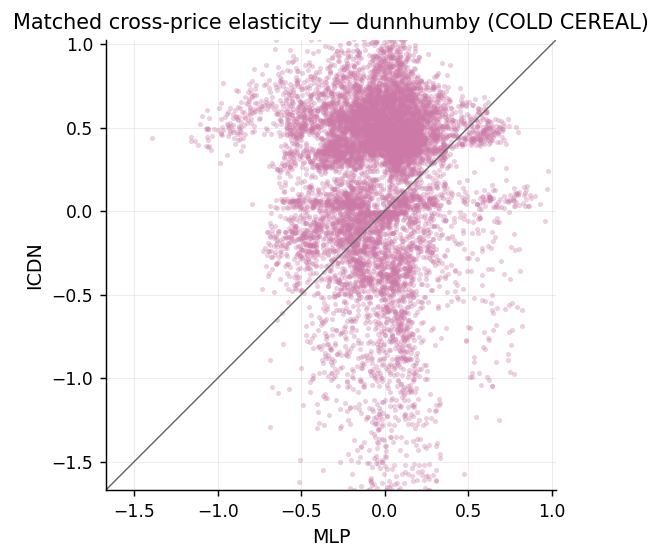

  figure /home/thebigmonster/Github/nn-elasticity-additional-work/notebooks/figures/dominick_matched_own_scatter.pdf


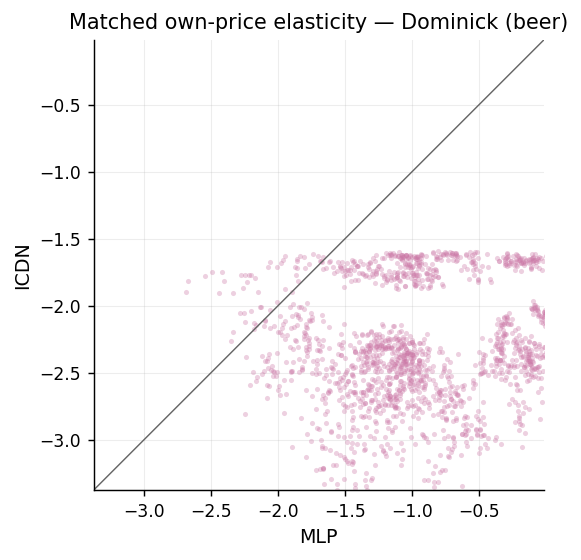

  figure /home/thebigmonster/Github/nn-elasticity-additional-work/notebooks/figures/dominick_matched_cross_scatter.pdf


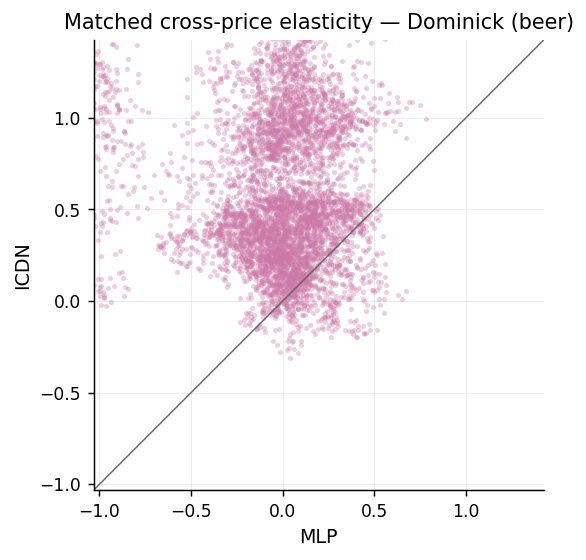

In [14]:
matched_e = pd.concat(
    [read_csv(p / "matched_elasticity_series.csv") for p in PANELS.values()],
    ignore_index=True,
)


def matched_agreement(df: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for (dataset, fold, a, b, kind), part in df.groupby(["dataset", "fold", "model_a", "model_b", "kind"]):
        d = pd.to_numeric(part["absolute_difference"], errors="coerce")
        rows.append({
            "dataset": dataset, "fold": fold, "model_a": a, "model_b": b, "kind": kind,
            "n_common": len(part),
            "share_same_sign": float(part["same_sign"].mean()) if "same_sign" in part.columns else np.nan,
            "median_abs_diff": float(d.median()),
            "mean_a": float(part["elasticity_a"].mean()),
            "mean_b": float(part["elasticity_b"].mean()),
        })
    return pd.DataFrame(rows).sort_values(["dataset", "fold", "kind", "model_b"])


if matched_e.empty:
    print("no matched_elasticity_series.csv")
else:
    show_table(matched_agreement(matched_e), "Table 11. Matched-edge agreement (ICDN vs MLP / Ridge / OLS)")


def plot_icdn_mlp_scatter(df: pd.DataFrame, dataset: str, kind: str, stem: str):
    part = df[(df["dataset"] == dataset) & (df["kind"] == kind) & (df["model_a"] == "icdn") & (df["model_b"] == "mlp")]
    if part.empty:
        return
    fig, ax = plt.subplots(figsize=(4.5, 4.5))
    ax.scatter(part["elasticity_b"], part["elasticity_a"], s=8, alpha=0.35, c=COLOR["icdn"], linewidths=0)
    lim = np.nanpercentile(np.r_[part["elasticity_a"], part["elasticity_b"]], [1, 99])
    ax.plot(lim, lim, color="0.4", lw=0.8)
    ax.set_xlim(lim)
    ax.set_ylim(lim)
    ax.set_xlabel("MLP")
    ax.set_ylabel("ICDN")
    ax.set_title(f"Matched {KIND_LABEL.get(kind, kind)} elasticity — {DATASET_LABEL[dataset]}")
    ax.set_aspect("equal", "box")
    savefig(fig, stem)
    plt.show()
    plt.close(fig)


if len(matched_e):
    for key in PANELS:
        plot_icdn_mlp_scatter(matched_e, key, "own", f"{key}_matched_own_scatter")
        plot_icdn_mlp_scatter(matched_e, key, "cross", f"{key}_matched_cross_scatter")


## 9. Holdout

The holdout is the point estimate contrasted with the bootstrap. `holdout_pred_cells.csv` is the common grid for that window. Point elasticities are in `holdout_elasticities.csv`.


In [15]:
hold_parts = []
for p in PANELS.values():
    df = load_all("holdout_elasticities.csv", p)
    if len(df):
        hold_parts.append(df)
hold = pd.concat(hold_parts, ignore_index=True) if hold_parts else pd.DataFrame()
if hold.empty:
    print("no holdout_elasticities")
else:
    hold = hold.copy()
    hold["outer_fold"] = "holdout"
    hold_dist = elasticity_distribution(hold)
    own = hold_dist[hold_dist["kind"].astype(str).isin(["own", "own_eq"])]
    cross = hold_dist[hold_dist["kind"].astype(str) == "cross"]
    if len(own):
        show_table(own[[c for c in OWN_COLS if c in own.columns]], "Table 12a. Holdout own-price elasticities")
    if len(cross):
        show_table(cross[[c for c in CROSS_COLS if c in cross.columns]], "Table 12b. Holdout cross-price elasticities")

hold_pred = matched_pred[matched_pred["fold"].astype(str) == "holdout"] if len(matched_pred) else pd.DataFrame()
if len(hold_pred):
    show_table(
        hold_pred[["dataset", "model_a", "model_b", "n_common_cells", "mae_a", "mae_b", "rmse_a", "rmse_b", "r2_a", "r2_b", "delta_mae"]],
        "Table 13. Matched-cell prediction on the holdout",
    )


**Table 12a. Holdout own-price elasticities**

      dataset  model     fold    kind     n     mean   median      std  \
1    dominick   icdn  holdout     own   400  -2.3383  -2.2939   0.2316   
3    dominick    mlp  holdout     own   400  -1.0353  -1.1187   0.5902   
5    dominick    ols  holdout     own   400  -4.7290  -4.8699   1.9298   
6    dominick    ols  holdout  own_eq  7151  -4.7154  -4.8426   2.0011   
8    dominick  ridge  holdout     own   400  -3.9746  -3.9574   1.9276   
9    dominick  ridge  holdout  own_eq  7151  -3.9583  -3.9026   2.0306   
11  dunnhumby   icdn  holdout     own   760  -0.0815  -0.0385   0.1706   
13  dunnhumby    mlp  holdout     own   760  -0.4937  -0.4866   0.3073   
15  dunnhumby    ols  holdout     own   732  -2.0077  -1.9940   1.2170   
16  dunnhumby    ols  holdout  own_eq  6419  -2.0024  -1.9932   1.2446   
18  dunnhumby  ridge  holdout     own   732  -1.5431  -1.3103   1.1259   
19  dunnhumby  ridge  holdout  own_eq  6419  -1.5376  -1.3109   1.1519   
21    walmart   icdn  holdout     own 

**Table 12b. Holdout cross-price elasticities**

      dataset  model     fold     n     mean   median      std     iqr  \
0    dominick   icdn  holdout  1600   0.2595   0.2729   0.2076  0.3591   
2    dominick    mlp  holdout  7600  -0.0251   0.0107   0.3187  0.3141   
4    dominick    ols  holdout  7151   0.0699   0.0976   1.5380  1.0141   
7    dominick  ridge  holdout  7151   0.0035   0.0156   1.2991  0.8249   
10  dunnhumby   icdn  holdout  2280   0.0818   0.0387   0.4676  0.8358   
12  dunnhumby    mlp  holdout  6840   0.0267   0.0506   0.2120  0.1880   
14  dunnhumby    ols  holdout  6419   0.0793   0.0948   0.6141  0.5787   
17  dunnhumby  ridge  holdout  6419   0.0498   0.0457   0.4511  0.3888   
20    walmart   icdn  holdout   400   0.4143   0.4305   0.2565  0.4550   
22    walmart    mlp  holdout  3800  -0.0310  -0.0230   0.1793  0.1795   
24    walmart    ols  holdout  3235  -1.2370  -0.0038  17.3051  2.3977   
27    walmart  ridge  holdout  3235  -0.2253  -0.0195   9.6539  1.4297   

        q025     q975 share_positive 

**Table 13. Matched-cell prediction on the holdout**

      dataset model_a model_b  n_common_cells   mae_a   mae_b  rmse_a  rmse_b  \
18    walmart    icdn     mlp            8453  0.5176  0.5736  0.6889  0.7584   
19    walmart    icdn   ridge            8007  0.5187  0.5525  0.6931  0.7823   
20    walmart    icdn     ols            8007  0.5187  0.5542  0.6931  0.7896   
21    walmart     mlp   ridge            8007  0.5740  0.5525  0.7619  0.7823   
22    walmart     mlp     ols            8007  0.5740  0.5542  0.7619  0.7896   
23    walmart   ridge     ols            8007  0.5525  0.5542  0.7823  0.7896   
42  dunnhumby    icdn     mlp           21059  0.5258  0.5623  0.6994  0.7584   
43  dunnhumby    icdn   ridge           20163  0.5329  0.4417  0.7081  0.6699   
44  dunnhumby    icdn     ols           20163  0.5329  0.4497  0.7081  0.6755   
45  dunnhumby     mlp   ridge           20163  0.5674  0.4417  0.7663  0.6699   
46  dunnhumby     mlp     ols           20163  0.5674  0.4497  0.7663  0.6755   
47  dunnhumby   ridge     ol

## 10. Bootstrap uncertainty

Each row of `bootstrap.csv` is a refit on non-overlapping blocks. `n_attempted` / `n_successful` document universe failures; replicas are not dropped silently.

`bootstrap_series_ci.csv` is the distribution **conditional** on the series appearing in that replica. `ci_width=q_{0.975}-q_{0.025}`. `bootstrap_matched.csv` keeps `freq ≥ 0.8`.

`bootstrap_matched_global.csv` is a descriptive summary by `kind` (median widths, median SD). It is **not** a CI for a global parameter.

Separate medians of ICDN and MLP SDs do not answer: *on the same series, how often is ICDN more stable?* That is the paired table below.


In [16]:
boot_parts = []
for p in PANELS.values():
    df = load_all("bootstrap.csv", p)
    if len(df):
        boot_parts.append(df)
boots = pd.concat(boot_parts, ignore_index=True) if boot_parts else pd.DataFrame()
if boots.empty:
    print("no bootstrap.csv")
else:
    cols = [c for c in [
        "dataset", "model", "boot", "mae_val", "rmse_val", "r2_val", "n_cells",
        "n_own", "n_cross", "own_mean", "cross_mean", "fit_seconds",
        "n_attempted", "n_successful",
    ] if c in boots.columns]
    show_table(boots[cols].sort_values(["dataset", "model", "boot"]), "Table 14. Bootstrap replicates (global behaviour)")

    fail = boots.groupby(["dataset", "model"], as_index=False).agg(
        n_successful=("boot", "nunique"),
        n_attempted=("n_attempted", "max"),
        mae_mean=("mae_val", "mean"),
        mae_sd=("mae_val", "std"),
    )
    fail["fail_rate"] = 1 - fail["n_successful"] / fail["n_attempted"].replace(0, np.nan)
    show_table(fail, "Table 15. Failure rate and predictive stability across replicates")


**Table 14. Bootstrap replicates (global behaviour)**

       dataset  model  boot mae_val rmse_val  r2_val  n_cells  n_own  n_cross  \
1100  dominick   icdn     0  0.4797   0.5992  0.7865    17215    400     1600   
1101  dominick   icdn     1  0.5197   0.6364  0.7592    17215    400     1600   
1102  dominick   icdn     2  0.5915   0.7069  0.7029    17215    400     1600   
1103  dominick   icdn     3  0.5665   0.6897  0.7171    17215    400     1600   
1104  dominick   icdn     4  0.6860   0.8893  0.5297    17215    400     1600   
...        ...    ...   ...     ...      ...     ...      ...    ...      ...   
195    walmart  ridge    95  0.5912   0.8369  0.5522     8007    191     3192   
196    walmart  ridge    96  0.4948   0.6821  0.6538     6285    146     2000   
197    walmart  ridge    97  0.5253   0.7435  0.6455     7822    185     3015   
198    walmart  ridge    98  0.5411   0.7568  0.6328     7822    185     2990   
199    walmart  ridge    99  0.5303   0.7450  0.6441     7822    185     3007   

     own_mean cross_mean fi

**Table 15. Failure rate and predictive stability across replicates**

      dataset  model  n_successful  n_attempted mae_mean  mae_sd fail_rate
0    dominick   icdn           100          100   0.5695  0.1400    0.0000
1    dominick    mlp           100          100   0.4885  0.1348    0.0000
2    dominick    ols           100          100   0.4993  0.0161    0.0000
3    dominick  ridge           100          100   0.4863  0.0135    0.0000
4   dunnhumby   icdn           100          100   0.5342  0.1019    0.0000
5   dunnhumby    mlp           100          100   0.6017  0.0479    0.0000
6   dunnhumby    ols           100          100   0.4672  0.0176    0.0000
7   dunnhumby  ridge           100          100   0.4528  0.0084    0.0000
8     walmart   icdn           100          100   0.5188  0.0846    0.0000
9     walmart    mlp           100          100   0.5483  0.2520    0.0000
10    walmart    ols           100          100   0.5697  0.0315    0.0000
11    walmart  ridge           100          100   0.5548  0.0251    0.0000


In [17]:
ci_parts = []
glob_parts = []
for p in PANELS.values():
    ci = load_all("bootstrap_series_ci.csv", p)
    if len(ci):
        ci_parts.append(ci)
    g = load_all("bootstrap_matched_global.csv", p)
    if len(g):
        if "dataset" not in g.columns:
            ds = (load_all("kfold.csv", p)["dataset"].iloc[0] if len(load_all("kfold.csv", p)) else p.parent.name)
            g = g.assign(dataset=ds)
        glob_parts.append(g)
all_ci = pd.concat(ci_parts, ignore_index=True) if ci_parts else pd.DataFrame()
all_glob = pd.concat(glob_parts, ignore_index=True) if glob_parts else pd.DataFrame()
if len(all_glob):
    show_table(all_glob, "Table 16. Matched bootstrap summary by kind (not a global CI)")


def ci_overview(ci: pd.DataFrame) -> pd.DataFrame:
    rows = []
    keep = ci[ci["matched"] == True] if "matched" in ci.columns else ci
    for (dataset, model, kind), part in keep.groupby(["dataset", "model", "kind"]):
        w = pd.to_numeric(part.get("ci_width"), errors="coerce")
        sd = pd.to_numeric(part.get("sd"), errors="coerce")
        rows.append({
            "dataset": dataset, "model": model, "kind": kind,
            "n_matched": len(part),
            "median_sd": float(sd.median()),
            "median_ci_width": float(w.median()) if w.notna().any() else np.nan,
            "median_share_positive": float(pd.to_numeric(part.get("share_positive"), errors="coerce").median()) if "share_positive" in part.columns else np.nan,
            "mean_freq": float(part["freq"].mean()) if "freq" in part.columns else np.nan,
        })
    out = pd.DataFrame(rows)
    out["model"] = pd.Categorical(out["model"], MODEL_ORDER, ordered=True)
    return out.sort_values(["dataset", "kind", "model"])


if len(all_ci):
    show_table(ci_overview(all_ci), "Table 17. Series-level uncertainty (matched only, freq ≥ 0.8)")


**Table 16. Matched bootstrap summary by kind (not a global CI)**

      kind  n_series mean_freq mean_conditional median_width median_sd  model  \
0    cross      2703    0.9598          -1.3733       5.1485    1.4001    ols   
1      own       181    0.9792           1.4285       6.1568    1.7023    ols   
2   own_eq      2703    0.9598           1.1433       6.7699    1.8298    ols   
3    cross      2703    0.9598          -0.2836       2.6604    0.7211  ridge   
4      own       181    0.9792           1.0385       3.0858    0.8741  ridge   
5   own_eq      2703    0.9598           0.7812       3.3172    0.8970  ridge   
6    cross      3800    1.0000           0.0010       0.6715    0.1808    mlp   
7      own       200    1.0000           0.1118       0.6369    0.1774    mlp   
8    cross       210    0.9900           0.4705       0.6280    0.1683   icdn   
9      own       200    1.0000          -0.1794       0.1812    0.0500   icdn   
10   cross      6091    0.9907           0.0651       1.2984    0.3463    ols   
11     own       702    0.99

**Table 17. Series-level uncertainty (matched only, freq ≥ 0.8)**

      dataset  model    kind  n_matched median_sd median_ci_width  \
4    dominick    ols   cross       6787    0.4894          1.8528   
7    dominick  ridge   cross       6787    0.4031          1.5182   
2    dominick    mlp   cross       7600    0.2459          0.9277   
0    dominick   icdn   cross        620    0.2544          0.9009   
5    dominick    ols     own        390    0.9921          3.7129   
8    dominick  ridge     own        390    0.6642          2.4714   
3    dominick    mlp     own        400    0.3688          1.4455   
1    dominick   icdn     own        400    0.4554          1.6951   
6    dominick    ols  own_eq       6787    1.0140          3.8275   
9    dominick  ridge  own_eq       6787    0.6963          2.5732   
14  dunnhumby    ols   cross       6091    0.3463          1.2984   
17  dunnhumby  ridge   cross       6091    0.2222          0.8358   
12  dunnhumby    mlp   cross       6840    0.1426          0.5431   
10  dunnhumby   icdn   cross      

  figure /home/thebigmonster/Github/nn-elasticity-additional-work/notebooks/figures/walmart_boot_width_own.pdf


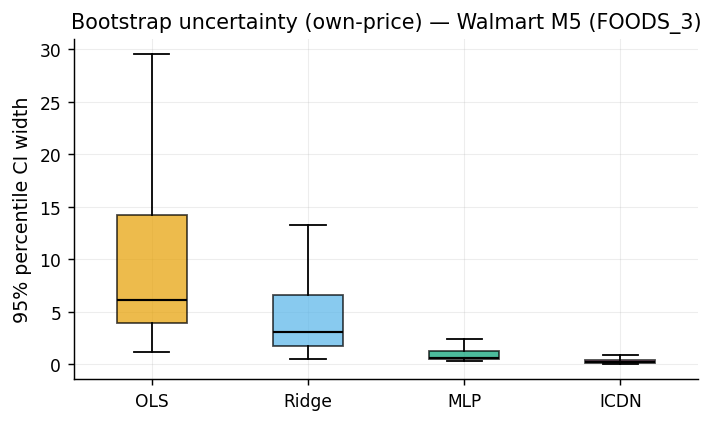

  figure /home/thebigmonster/Github/nn-elasticity-additional-work/notebooks/figures/walmart_boot_width_cross.pdf


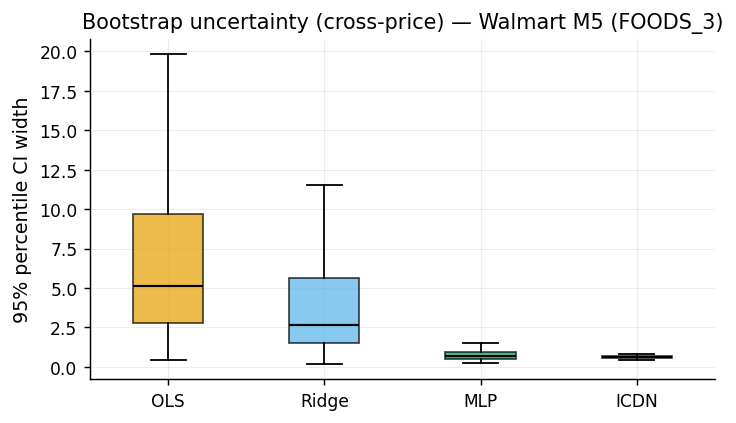

  figure /home/thebigmonster/Github/nn-elasticity-additional-work/notebooks/figures/dunnhumby_boot_width_own.pdf


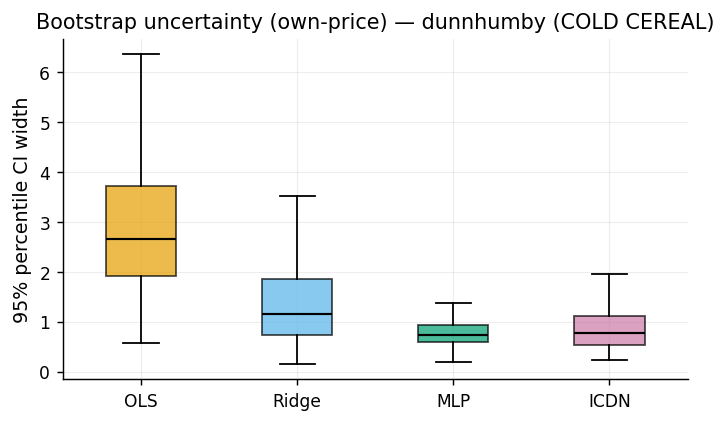

  figure /home/thebigmonster/Github/nn-elasticity-additional-work/notebooks/figures/dunnhumby_boot_width_cross.pdf


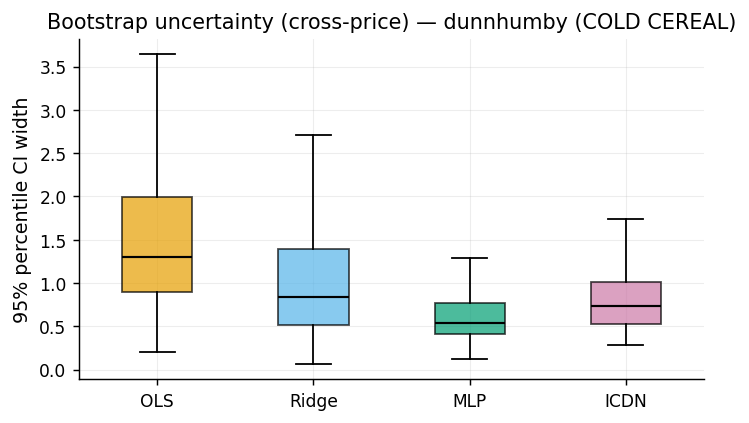

  figure /home/thebigmonster/Github/nn-elasticity-additional-work/notebooks/figures/dominick_boot_width_own.pdf


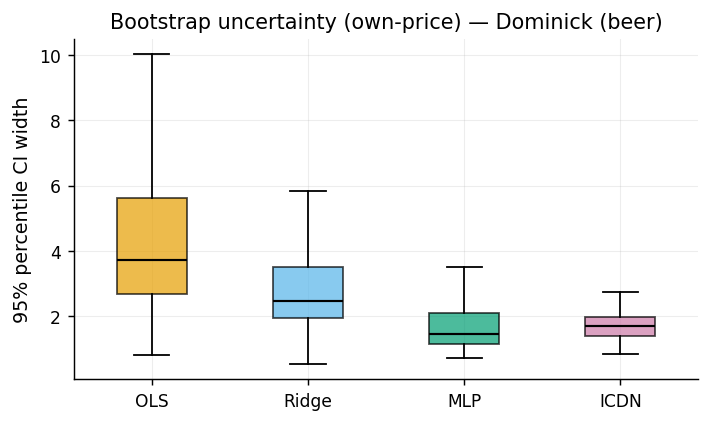

  figure /home/thebigmonster/Github/nn-elasticity-additional-work/notebooks/figures/dominick_boot_width_cross.pdf


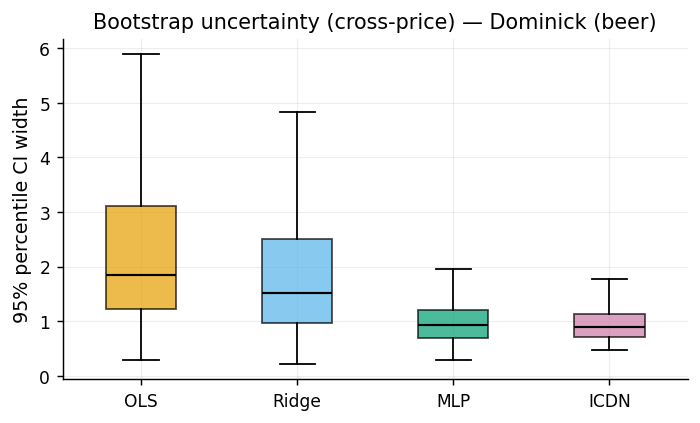

In [18]:
def plot_ci_width(ci: pd.DataFrame, dataset: str, kind: str, stem: str):
    df = ci[(ci["dataset"] == dataset) & (ci["kind"] == kind)].copy()
    if "matched" in df.columns:
        df = df[df["matched"] == True]
    if df.empty or "ci_width" not in df.columns:
        return
    fig, ax = plt.subplots(figsize=(6.2, 3.4))
    data, labels, colors = [], [], []
    for model in MODEL_ORDER:
        part = pd.to_numeric(df.loc[df["model"] == model, "ci_width"], errors="coerce").dropna()
        if part.empty:
            continue
        data.append(part.to_numpy())
        labels.append(MODEL_LABEL[model])
        colors.append(COLOR[model])
    if not data:
        return
    bp = ax.boxplot(data, patch_artist=True, showfliers=False, medianprops={"color": "black", "linewidth": 1.2})
    ax.set_xticks(range(1, len(labels) + 1))
    ax.set_xticklabels(labels)
    for patch, c in zip(bp["boxes"], colors):
        patch.set_facecolor(c)
        patch.set_alpha(0.7)
    ax.set_ylabel("95% percentile CI width")
    ax.set_title(f"Bootstrap uncertainty ({KIND_LABEL.get(kind, kind)}) — {DATASET_LABEL[dataset]}")
    savefig(fig, stem)
    plt.show()
    plt.close(fig)


if len(all_ci):
    for key in PANELS:
        plot_ci_width(all_ci, key, "own", f"{key}_boot_width_own")
        plot_ci_width(all_ci, key, "cross", f"{key}_boot_width_cross")


### Paired ICDN–MLP bootstrap stability

**Table 18. Paired ICDN–MLP bootstrap stability (common replicate IDs)**

     dataset   kind  n_series  n_series_sd_defined p_sd_icdn_lt_mlp  \
0    walmart  cross       860                  710           0.3014   
1    walmart    own       200                  200           0.8100   
2  dunnhumby  cross      5548                 4484           0.2872   
3  dunnhumby    own       760                  760           0.4066   
4   dominick  cross      5260                 4540           0.4035   
5   dominick    own       400                  400           0.3475   

  p_width_icdn_lt_mlp median_sd_diff median_width_diff  \
0              0.3085         0.0335            0.1180   
1              0.8000        -0.1055           -0.4237   
2              0.2881         0.1148            0.3233   
3              0.4303         0.0416            0.0753   
4              0.4110         0.0647            0.1515   
5              0.3600         0.1183            0.3583   

  median_n_common_bootstrap_ids mean_common_bootstrap_frequency  \
0                       47.0

**paired_bootstrap_stability.csv (first rows; one row per series)**

   dataset store_code    product_i    product_j   kind  \
0  walmart       CA_1  FOODS_3_041  FOODS_3_041    own   
1  walmart       CA_1  FOODS_3_041  FOODS_3_098  cross   
2  walmart       CA_1  FOODS_3_041  FOODS_3_448  cross   
3  walmart       CA_1  FOODS_3_098  FOODS_3_041  cross   
4  walmart       CA_1  FOODS_3_098  FOODS_3_098    own   
5  walmart       CA_1  FOODS_3_098  FOODS_3_448  cross   
6  walmart       CA_1  FOODS_3_115  FOODS_3_041  cross   
7  walmart       CA_1  FOODS_3_115  FOODS_3_098  cross   

   n_common_bootstrap_ids common_bootstrap_frequency edge_selection_frequency  \
0                     100                     1.0000                   1.0000   
1                      99                     0.9900                   0.9900   
2                      66                     0.6600                   0.6600   
3                     100                     1.0000                   1.0000   
4                     100                     1.0000                   1

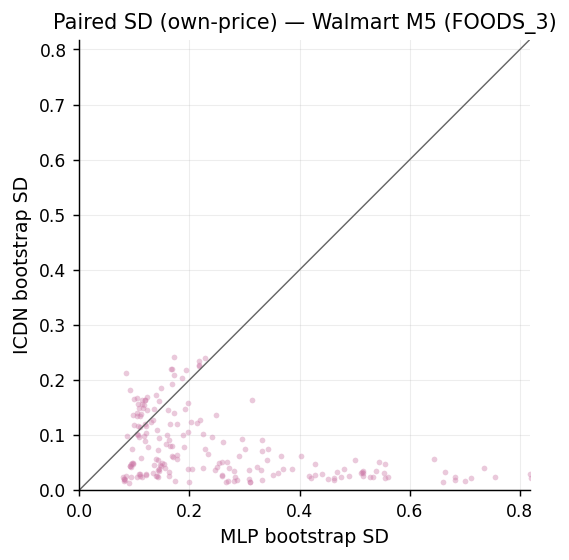

  figure /home/thebigmonster/Github/nn-elasticity-additional-work/notebooks/figures/walmart_paired_boot_sd_cross.pdf


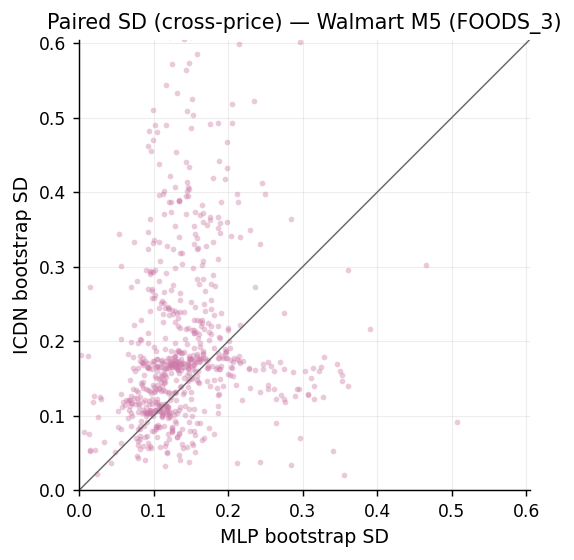

  figure /home/thebigmonster/Github/nn-elasticity-additional-work/notebooks/figures/dunnhumby_paired_boot_sd_own.pdf


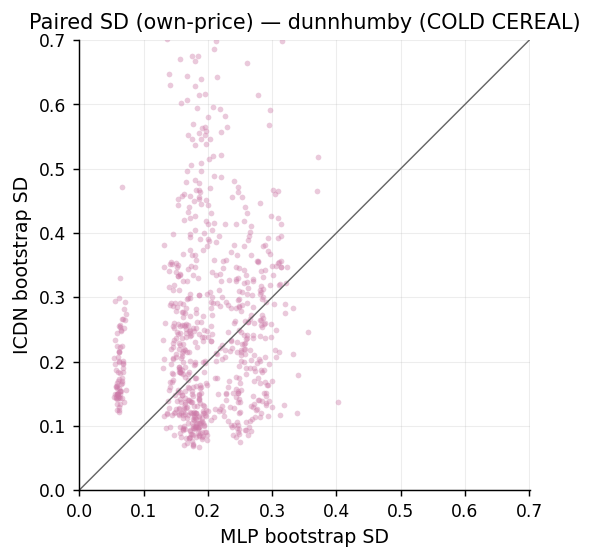

  figure /home/thebigmonster/Github/nn-elasticity-additional-work/notebooks/figures/dunnhumby_paired_boot_sd_cross.pdf


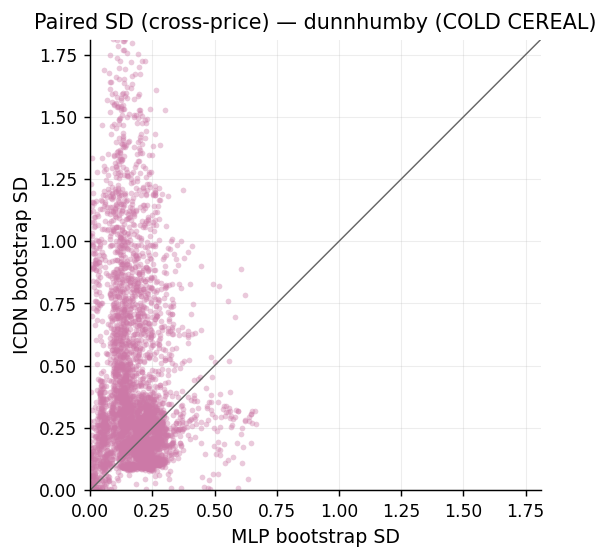

  figure /home/thebigmonster/Github/nn-elasticity-additional-work/notebooks/figures/dominick_paired_boot_sd_own.pdf


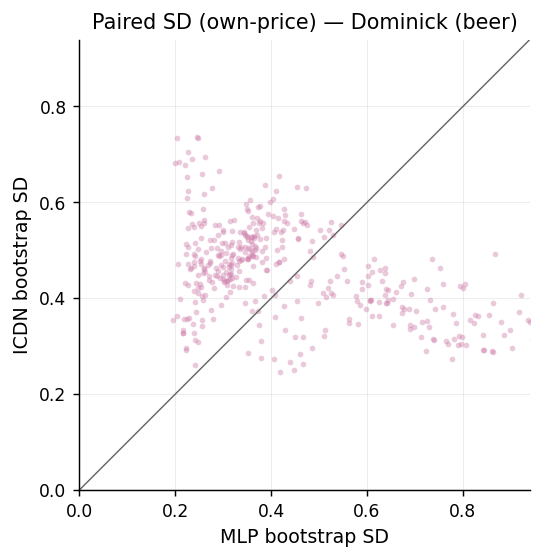

  figure /home/thebigmonster/Github/nn-elasticity-additional-work/notebooks/figures/dominick_paired_boot_sd_cross.pdf


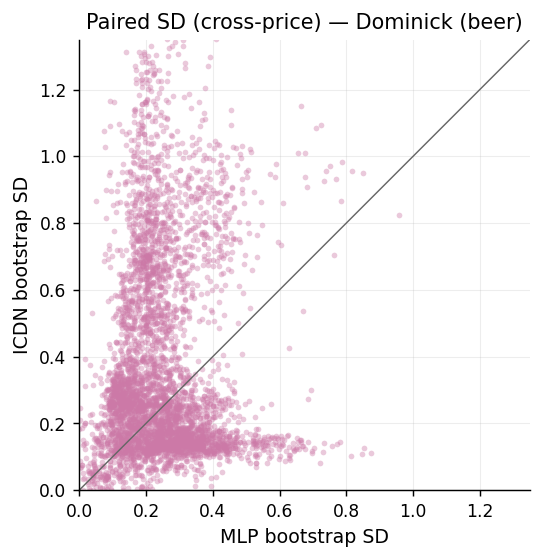

In [19]:
stab = pd.concat(
    [read_csv(p / "paired_bootstrap_stability.csv") for p in PANELS.values()],
    ignore_index=True,
)
stab_sum = pd.concat(
    [read_csv(p / "paired_bootstrap_summary.csv") for p in PANELS.values()],
    ignore_index=True,
)
if stab_sum.empty:
    print("paired_bootstrap_summary.csv missing.")
else:
    show_table(stab_sum, "Table 18. Paired ICDN–MLP bootstrap stability (common replicate IDs)")
if len(stab):
    show_table(
        stab.head(8)[[c for c in [
            "dataset", "store_code", "product_i", "product_j", "kind",
            "n_common_bootstrap_ids", "common_bootstrap_frequency", "edge_selection_frequency",
            "sd_icdn", "sd_mlp", "sd_diff", "width_icdn", "width_mlp",
        ] if c in stab.columns]],
        "paired_bootstrap_stability.csv (first rows; one row per series)",
    )


def plot_paired_sd(series: pd.DataFrame, dataset: str, kind: str, stem: str):
    part = series[(series["dataset"] == dataset) & (series["kind"] == kind)].dropna(subset=["sd_icdn", "sd_mlp"])
    if part.empty:
        return
    fig, ax = plt.subplots(figsize=(4.5, 4.5))
    ax.scatter(part["sd_mlp"], part["sd_icdn"], s=10, alpha=0.4, c=COLOR["icdn"], linewidths=0)
    hi = np.nanpercentile(np.r_[part["sd_icdn"], part["sd_mlp"]], 99)
    ax.plot([0, hi], [0, hi], color="0.4", lw=0.8)
    ax.set_xlim(0, hi)
    ax.set_ylim(0, hi)
    ax.set_xlabel("MLP bootstrap SD")
    ax.set_ylabel("ICDN bootstrap SD")
    ax.set_title(f"Paired SD ({KIND_LABEL.get(kind, kind)}) — {DATASET_LABEL[dataset]}")
    ax.set_aspect("equal", "box")
    savefig(fig, stem)
    plt.show()
    plt.close(fig)


if len(stab):
    for key in PANELS:
        plot_paired_sd(stab, key, "own", f"{key}_paired_boot_sd_own")
        plot_paired_sd(stab, key, "cross", f"{key}_paired_boot_sd_cross")


### Holdout inside the bootstrap CI, boot/fold SD ratio, folds inside the CI

`holdout_in_boot_ci.csv` asks whether the holdout point lies in [q_0.025, q_0.975] of its series. `boot_fold_ratio.csv` compares bootstrap SD with temporal SD; `zero_fold_sd_flag` marks series with no fold variation. `fold_in_boot_ci.csv` is the share of outer-fold estimates inside the bootstrap interval.


In [20]:
def rate_table(df: pd.DataFrame, flag: str, extra_group=()) -> pd.DataFrame:
    keys = ["dataset", "model", "kind", *extra_group]
    keys = [k for k in keys if k in df.columns]
    rows = []
    for key, part in df.groupby(keys):
        rec = dict(zip(keys, key if isinstance(key, tuple) else (key,)))
        rec["n"] = len(part)
        rec["share"] = float(part[flag].mean())
        rows.append(rec)
    return pd.DataFrame(rows)


hold_ci_parts, ratio_parts, fold_ci_parts = [], [], []
for p in PANELS.values():
    a = load_all("holdout_in_boot_ci.csv", p)
    if len(a):
        hold_ci_parts.append(a)
    b = load_all("boot_fold_ratio.csv", p)
    if len(b):
        ratio_parts.append(b)
    c = load_all("fold_in_boot_ci.csv", p)
    if len(c):
        fold_ci_parts.append(c)
hold_ci = pd.concat(hold_ci_parts, ignore_index=True) if hold_ci_parts else pd.DataFrame()
ratio = pd.concat(ratio_parts, ignore_index=True) if ratio_parts else pd.DataFrame()
fold_ci = pd.concat(fold_ci_parts, ignore_index=True) if fold_ci_parts else pd.DataFrame()

if len(hold_ci) and "in_boot_ci" in hold_ci.columns:
    show_table(rate_table(hold_ci, "in_boot_ci"), "Table 19. Share of holdout points inside the bootstrap CI")
if len(fold_ci) and "inside_boot_ci" in fold_ci.columns:
    show_table(rate_table(fold_ci, "inside_boot_ci", extra_group=("outer_fold",)), "Table 20. Share of fold elasticities inside the bootstrap CI")
if len(ratio):
    overview = []
    for (dataset, model, kind), part in ratio.groupby(["dataset", "model", "kind"]):
        r = pd.to_numeric(part.get("sd_ratio_boot_fold"), errors="coerce")
        r = r.replace([np.inf, -np.inf], np.nan)
        overview.append({
            "dataset": dataset, "model": model, "kind": kind,
            "n": len(part),
            "median_sd_ratio": float(r.median()),
            "share_zero_fold_sd": float(part["zero_fold_sd_flag"].mean()) if "zero_fold_sd_flag" in part.columns else np.nan,
        })
    show_table(pd.DataFrame(overview).sort_values(["dataset", "kind", "model"]),
               "Table 21. Bootstrap SD / between-fold SD (matched series)")


**Table 19. Share of holdout points inside the bootstrap CI**

      dataset  model    kind     n   share
0    dominick   icdn   cross   620  1.0000
1    dominick   icdn     own   400  0.8175
2    dominick    mlp   cross  7600  0.9858
3    dominick    mlp     own   400  1.0000
4    dominick    ols   cross  6787  1.0000
5    dominick    ols     own   390  1.0000
6    dominick    ols  own_eq  6787  1.0000
7    dominick  ridge   cross  6787  1.0000
8    dominick  ridge     own   390  1.0000
9    dominick  ridge  own_eq  6787  1.0000
10  dunnhumby   icdn   cross  1824  0.8328
11  dunnhumby   icdn     own   760  0.8684
12  dunnhumby    mlp   cross  6840  0.9689
13  dunnhumby    mlp     own   760  0.9803
14  dunnhumby    ols   cross  6091  1.0000
15  dunnhumby    ols     own   702  1.0000
16  dunnhumby    ols  own_eq  6091  1.0000
17  dunnhumby  ridge   cross  6091  1.0000
18  dunnhumby  ridge     own   702  1.0000
19  dunnhumby  ridge  own_eq  6091  1.0000
20    walmart   icdn   cross   210  1.0000
21    walmart   icdn     own   200  0.9950
22    walma

**Table 20. Share of fold elasticities inside the bootstrap CI**

     dataset  model    kind  outer_fold     n   share
0   dominick   icdn   cross           1   440  0.5705
1   dominick   icdn   cross           2   720  0.0000
2   dominick   icdn   cross           3   860  0.9837
3   dominick   icdn     own           1   400  0.0000
4   dominick   icdn     own           2   400  1.0000
..       ...    ...     ...         ...   ...     ...
85   walmart  ridge     own           2   191  0.8953
86   walmart  ridge     own           3   191  1.0000
87   walmart  ridge  own_eq           1  2593  0.7270
88   walmart  ridge  own_eq           2  3180  0.9003
89   walmart  ridge  own_eq           3  3228  0.9827

[90 rows x 6 columns]


**Table 21. Bootstrap SD / between-fold SD (matched series)**

      dataset  model    kind     n median_sd_ratio share_zero_fold_sd
0    dominick   icdn   cross   500          0.5330             0.2400
2    dominick    mlp   cross  7600          2.3002             0.0000
4    dominick    ols   cross  6787          1.7571             0.0090
7    dominick  ridge   cross  6787          1.5869             0.0090
1    dominick   icdn     own   400          0.7754             0.0000
3    dominick    mlp     own   400          2.1848             0.0000
5    dominick    ols     own   390          2.0305             0.0000
8    dominick  ridge     own   390          1.0736             0.0000
6    dominick    ols  own_eq  6787          1.9656             0.0090
9    dominick  ridge  own_eq  6787          0.9850             0.0090
10  dunnhumby   icdn   cross  1824          0.4421             0.0033
12  dunnhumby    mlp   cross  6840          1.2322             0.0000
14  dunnhumby    ols   cross  6091          2.0688             0.0005
17  dunnhumby  ridge

## 11. Optuna


**Table 22. Optuna budget and winning configuration (COMPLETE trials only)**

      dataset model    stage  n_trials  completed  pruned  failed best_value  \
0    dominick  icdn    fold1       100         34      66       0     0.4372   
1    dominick  icdn    fold2       100         28      72       0     0.4554   
2    dominick  icdn    fold3       100         48      52       0     0.4440   
3    dominick  icdn  holdout       100         33      67       0     0.4436   
4    dominick   mlp    fold1       100         56      44       0     0.4275   
5    dominick   mlp    fold2       100         44      56       0     0.4196   
6    dominick   mlp    fold3       100         55      45       0     0.4094   
7    dominick   mlp  holdout       100         49      51       0     0.4089   
8   dunnhumby  icdn    fold1       100         55      45       0     0.4562   
9   dunnhumby  icdn    fold2       100         40      60       0     0.4474   
10  dunnhumby  icdn    fold3       100         32      68       0     0.4612   
11  dunnhumby  icdn  holdout       100  

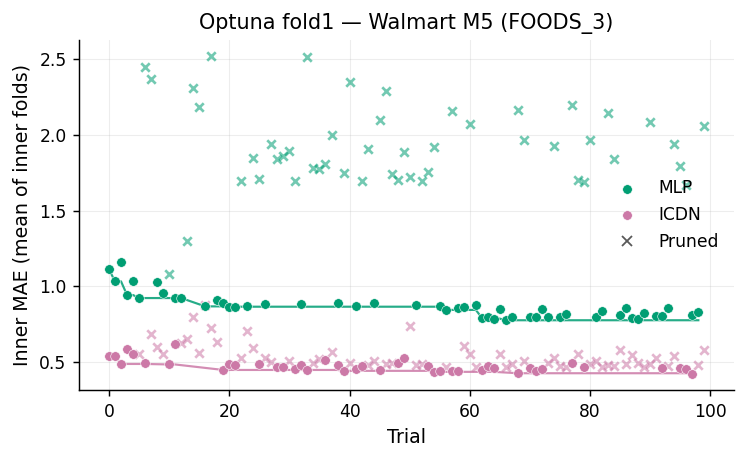

  figure /home/thebigmonster/Github/nn-elasticity-additional-work/notebooks/figures/walmart_optuna_fold2.pdf


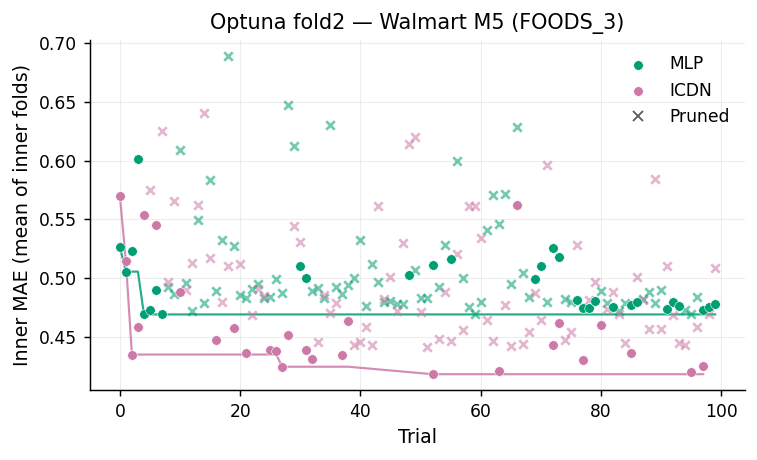

  figure /home/thebigmonster/Github/nn-elasticity-additional-work/notebooks/figures/walmart_optuna_fold3.pdf


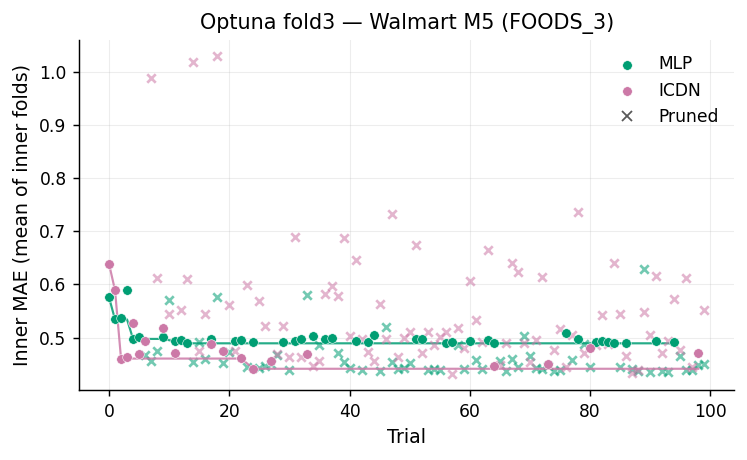

  figure /home/thebigmonster/Github/nn-elasticity-additional-work/notebooks/figures/walmart_optuna_holdout.pdf


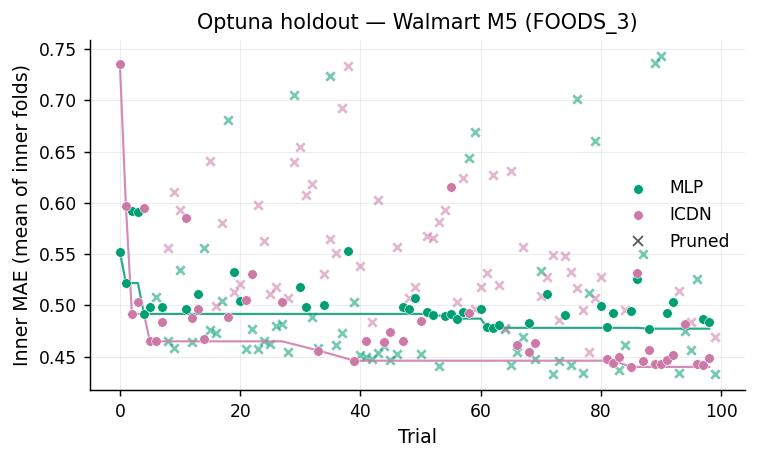

  figure /home/thebigmonster/Github/nn-elasticity-additional-work/notebooks/figures/dunnhumby_optuna_fold1.pdf


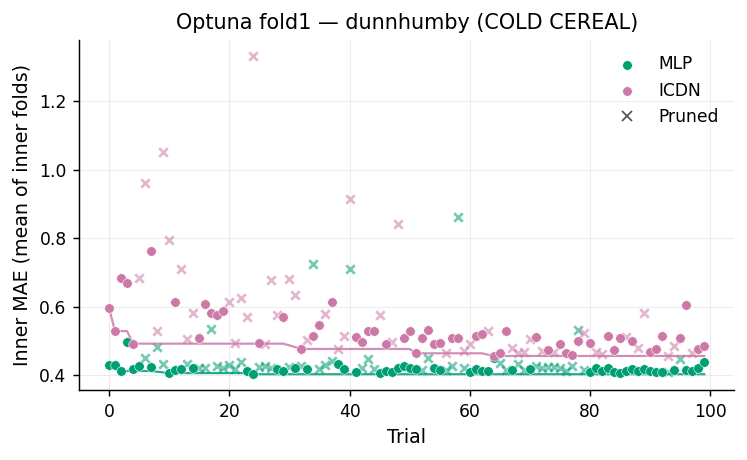

  figure /home/thebigmonster/Github/nn-elasticity-additional-work/notebooks/figures/dunnhumby_optuna_fold2.pdf


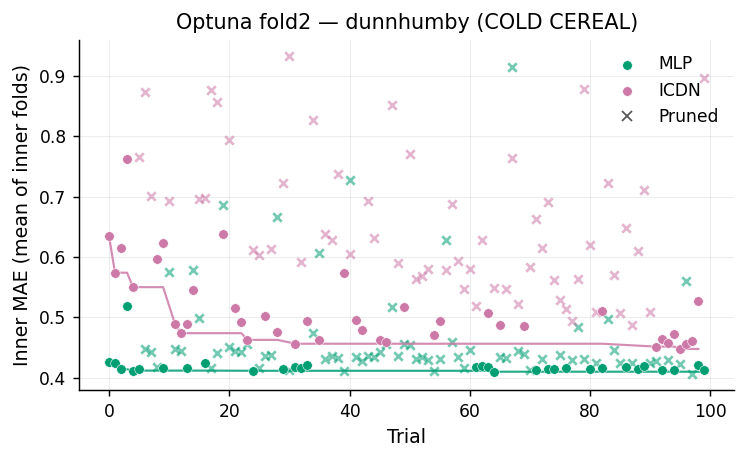

  figure /home/thebigmonster/Github/nn-elasticity-additional-work/notebooks/figures/dunnhumby_optuna_fold3.pdf


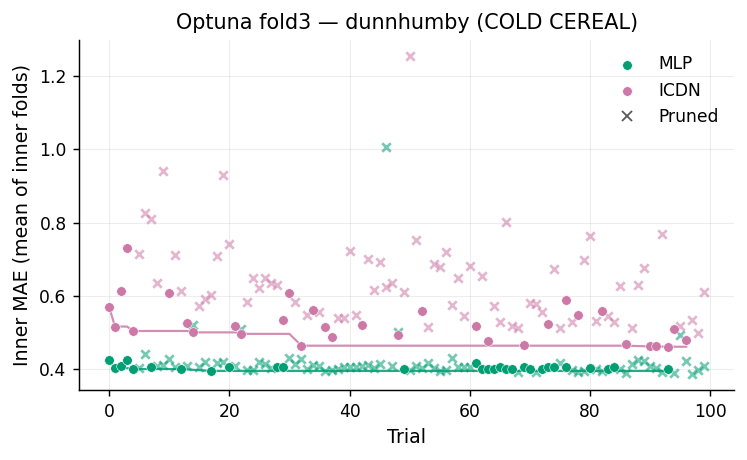

  figure /home/thebigmonster/Github/nn-elasticity-additional-work/notebooks/figures/dunnhumby_optuna_holdout.pdf


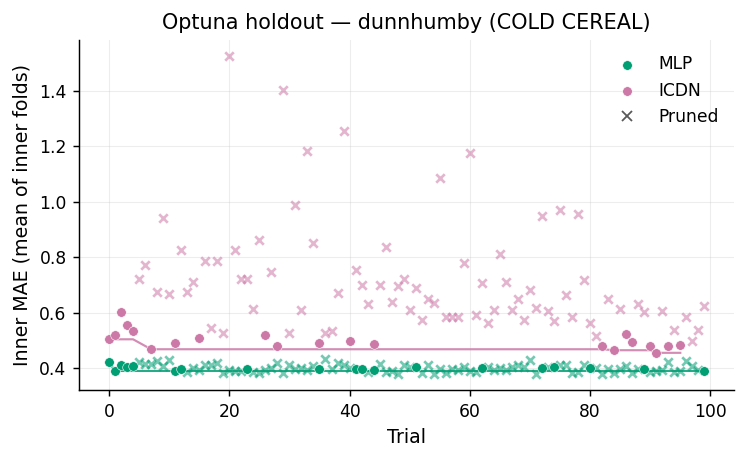

  figure /home/thebigmonster/Github/nn-elasticity-additional-work/notebooks/figures/dominick_optuna_fold1.pdf


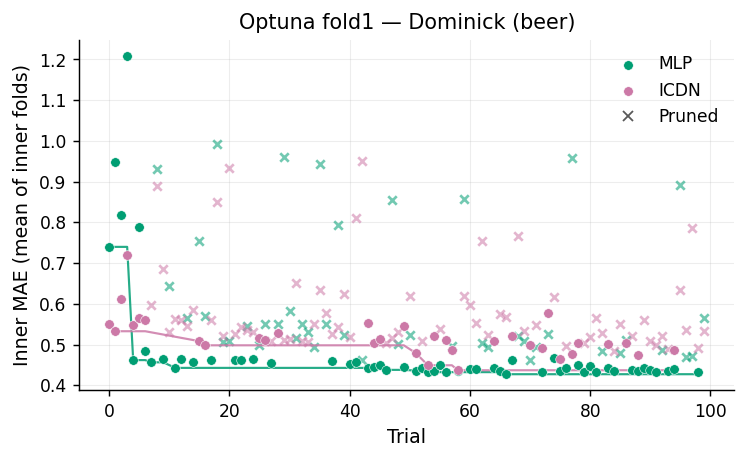

  figure /home/thebigmonster/Github/nn-elasticity-additional-work/notebooks/figures/dominick_optuna_fold2.pdf


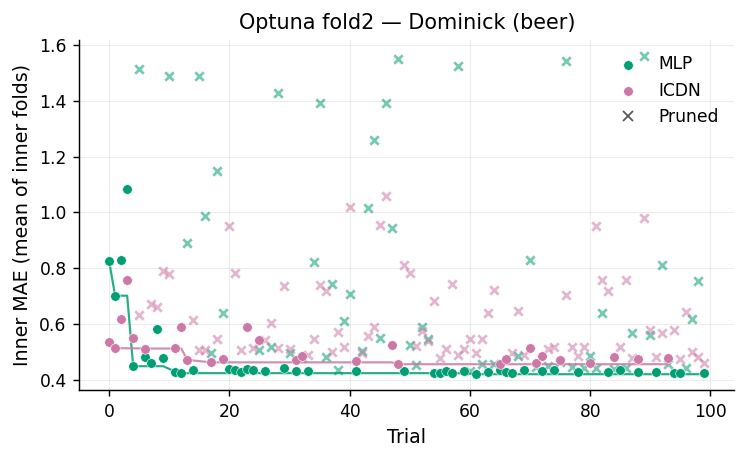

  figure /home/thebigmonster/Github/nn-elasticity-additional-work/notebooks/figures/dominick_optuna_fold3.pdf


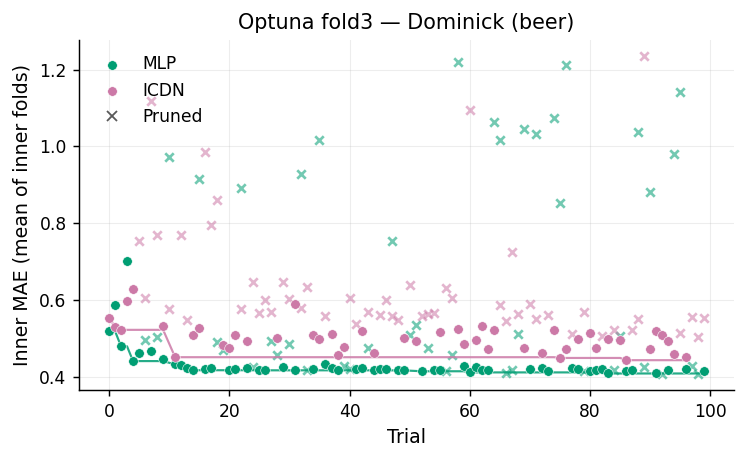

  figure /home/thebigmonster/Github/nn-elasticity-additional-work/notebooks/figures/dominick_optuna_holdout.pdf


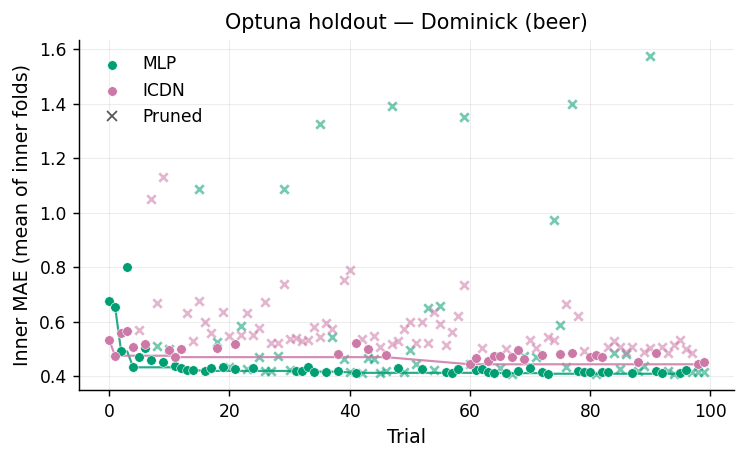

In [21]:
def load_optuna(panel: Path) -> pd.DataFrame:
    rows = []
    for model in NEURAL_MODELS:
        for path in sorted((panel / model).glob("*/optuna_trials.csv")):
            df = read_csv(path)
            if df.empty:
                continue
            df = df.copy()
            df["model"] = model
            df["stage"] = path.parent.name
            ds = load_all("kfold.csv", panel)
            df["dataset"] = ds["dataset"].iloc[0] if len(ds) else panel.parent.name
            rows.append(df)
    return pd.concat(rows, ignore_index=True) if rows else pd.DataFrame()


opt = pd.concat([load_optuna(p) for p in PANELS.values()], ignore_index=True)
if opt.empty:
    print("no optuna_trials.csv")
else:
    mae_cols = [c for c in opt.columns if c.startswith("user_attrs_fold") and c.endswith("_mae")]

    def trial_budget(df: pd.DataFrame) -> pd.DataFrame:
        rows = []
        for (dataset, model, stage), part in df.groupby(["dataset", "model", "stage"]):
            states = part["state"].astype(str)
            best = best_complete_trial(part)
            rec = {
                "dataset": dataset, "model": model, "stage": stage,
                "n_trials": len(part),
                "completed": int((states == "COMPLETE").sum()),
                "pruned": int((states == "PRUNED").sum()),
                "failed": int((states == "FAIL").sum()),
                "best_value": float(best["value"]) if best is not None else np.nan,
            }
            if best is not None:
                rec["best_hidden"] = best.get("params_hidden", np.nan)
                rec["best_dropout"] = best.get("params_dropout", np.nan)
                rec["best_lr"] = best.get("params_lr", np.nan)
                inner = [best[c] for c in mae_cols if c in best.index and pd.notna(best[c])]
                rec["best_inner_mae_sd"] = float(np.std(inner)) if inner else np.nan
            rows.append(rec)
        return pd.DataFrame(rows).sort_values(["dataset", "model", "stage"])

    show_table(trial_budget(opt), "Table 22. Optuna budget and winning configuration (COMPLETE trials only)")

    def plot_optuna(df: pd.DataFrame, dataset: str, stage: str, stem: str):
        part = df[(df["dataset"] == dataset) & (df["stage"] == stage)]
        if part.empty:
            return
        fig, ax = plt.subplots(figsize=(6.5, 3.5))
        for model in NEURAL_MODELS:
            m = part[part["model"] == model].sort_values("number")
            if m.empty:
                continue
            complete = m[m["state"].astype(str) == "COMPLETE"]
            pruned = m[m["state"].astype(str) == "PRUNED"]
            if len(pruned):
                ax.scatter(pruned["number"], pruned["value"], s=22, marker="x", color=COLOR[model], alpha=0.55, zorder=2)
            if len(complete):
                ax.scatter(complete["number"], complete["value"], s=28, marker="o", color=COLOR[model], label=MODEL_LABEL[model], zorder=3, edgecolors="white", linewidths=0.3)
                ax.plot(complete["number"], complete["value"].cummin(), color=COLOR[model], lw=1.2, alpha=0.85)
        ax.set_xlabel("Trial")
        ax.set_ylabel("Inner MAE (mean of inner folds)")
        ax.set_title(f"Optuna {stage} — {DATASET_LABEL[dataset]}")
        handles, labels = ax.get_legend_handles_labels()
        handles.append(Line2D([0], [0], marker="x", color="0.35", linestyle="none", label="Pruned"))
        labels.append("Pruned")
        ax.legend(handles, labels)
        savefig(fig, stem)
        plt.show()
        plt.close(fig)

    for key in PANELS:
        stages = sorted(opt.loc[opt["dataset"] == key, "stage"].unique()) if "dataset" in opt.columns else []
        for st in stages:
            plot_optuna(opt, key, st, f"{key}_optuna_{st}")


## 12. Protocol audit

`split_plan.json` / `split_plan.csv` is the shared cut: the later of the default floor, the MLP minimum, and the ICDN minimum. OLS, Ridge, MLP, and ICDN read that manifest; they do not choose their own outer fold.

`bootstrap_plan.json` is the shared draw: each replica stores source blocks, `bootstrap_order`, validation weeks, and the frozen calendar of the original holdout train. All four models read that plan.

`run_manifest.csv` records train / early-stop / validation clocks, the frozen-universe hash, and the seed. The four models must share `frozen_products_hash` and the same validation window in a given fold.

`bootstrap_manifest.csv` flattens block JSON. `period_overlap_flag` is true if the same `source_week` enters two blocks of a replica (sampling with replacement of the partition). Validation is never resampled.

`run_failures.csv` lists omitted folds/replicas. `spline_support_diagnostics.csv` counts observed log-prices outside ICDN spline knots (cubic extrapolation).


In [22]:
man_parts, fail_parts, spl_parts, bman_parts, plan_parts = [], [], [], [], []
for p in PANELS.values():
    man_parts.append(read_csv(p / "run_manifest.csv"))
    fail_parts.append(read_csv(p / "run_failures.csv"))
    spl_parts.append(read_csv(p / "spline_support_diagnostics.csv"))
    bman_parts.append(read_csv(p / "bootstrap_manifest.csv"))
    plan_parts.append(read_csv(p / "split_plan.csv"))
manifest = pd.concat([x for x in man_parts if len(x)], ignore_index=True) if any(len(x) for x in man_parts) else pd.DataFrame()
failures = pd.concat([x for x in fail_parts if len(x)], ignore_index=True) if any(len(x) for x in fail_parts) else pd.DataFrame()
spline = pd.concat([x for x in spl_parts if len(x)], ignore_index=True) if any(len(x) for x in spl_parts) else pd.DataFrame()
bman = pd.concat([x for x in bman_parts if len(x)], ignore_index=True) if any(len(x) for x in bman_parts) else pd.DataFrame()
plans = pd.concat([x for x in plan_parts if len(x)], ignore_index=True) if any(len(x) for x in plan_parts) else pd.DataFrame()

if plans.empty:
    print("split_plan.csv missing.")
else:
    show_table(plans.sort_values(["dataset", "fold"]), "Shared split plan (one manifest per dataset)")

boot_plan_rows = []
for key, p in PANELS.items():
    path = p / "bootstrap_plan.json"
    if not path.exists():
        continue
    payload = json.loads(path.read_text())
    cal = payload.get("calendar") or {}
    boot_plan_rows.append({
        "dataset": payload.get("dataset", key),
        "n_boot": payload.get("n_boot"),
        "n_train_periods": payload.get("n_train_periods"),
        "block_size": payload.get("block_size"),
        "seed": payload.get("seed"),
        "calendar_origin": cal.get("origin"),
        "max_train_rank": cal.get("max_train_rank"),
        "n_val_weeks": len(payload.get("val_weeks") or []),
        "n_replicates": len(payload.get("replicates") or []),
    })
if boot_plan_rows:
    show_table(pd.DataFrame(boot_plan_rows), "Shared bootstrap plan (one draw per dataset)")
else:
    print("bootstrap_plan.json missing.")

if len(manifest):
    show_table(manifest.sort_values(["dataset", "outer_fold", "model"]), "Table 23. Split manifest")
    hash_ok = (
        manifest.groupby(["dataset", "stage", "outer_fold"])["frozen_products_hash"]
        .nunique()
        .rename("n_distinct_universe_hashes")
        .reset_index()
    )
    show_table(hash_ok, "One frozen universe per split (must be 1)")
    val_ok = (
        manifest.groupby(["dataset", "stage", "outer_fold"])
        .agg(n_val_min=("validation_week_min", "nunique"), n_val_max=("validation_week_max", "nunique"))
        .reset_index()
    )
    show_table(val_ok, "Same validation window per split (nunique must be 1)")

if bman.empty:
    print("bootstrap_manifest.csv has no rows.")
else:
    show_table(bman.head(20), "Table 24. First bootstrap blocks (sample)")
    same = (
        bman.groupby(["dataset", "bootstrap_id", "source_block_id"])
        .agg(
            n_models=("model", "nunique"),
            n_source_start=("source_week_start", "nunique"),
            n_boot_start=("bootstrap_week_start", "nunique"),
            any_overlap=("period_overlap_flag", "max"),
        )
        .reset_index()
    )
    show_table(same, "Blocks aligned across models (n_source_start = 1 and n_boot_start = 1)")

if failures.empty:
    print("run_failures.csv empty: no recorded skips.")
else:
    show_table(failures, "Table 25. Omitted folds / trials / replicates")

if spline.empty or spline.dropna(how="all").empty:
    print("spline_support_diagnostics.csv empty until the next ICDN fit.")
else:
    show_table(spline, "Table 26. ICDN spline-support extrapolation")


**Shared split plan (one manifest per dataset)**

      dataset     fold  train_week_min  train_week_max  val_week_min  \
8    dominick        1               1             110           111   
9    dominick        2               1             146           147   
10   dominick        3               1             182           183   
11   dominick  holdout               1             176           177   
4   dunnhumby        1               1              78            79   
5   dunnhumby        2               1             104           105   
6   dunnhumby        3               1             130           131   
7   dunnhumby  holdout               1             124           125   
0     walmart        1               1             138           139   
1     walmart        2               1             184           185   
2     walmart        3               1             230           231   
3     walmart  holdout               1             221           222   

    val_week_max  n_train_periods  n_val_periods  min_train  n_

**Shared bootstrap plan (one draw per dataset)**

     dataset  n_boot  n_train_periods  block_size  seed  calendar_origin  \
0    walmart     100              221          20    42                1   
1  dunnhumby     100              124          20    42                1   
2   dominick     100              176          20    42                1   

   max_train_rank  n_val_weeks  n_replicates  
0             221           56           100  
1             124           32           100  
2             176           44           100  


**Table 23. Split manifest**

...

    dataset model  bootstrap_id  source_block_id  source_week_start  \
0   walmart   ols             0                0                 21   
1   walmart   ols             0                1                181   
2   walmart   ols             0                2                141   
3   walmart   ols             0                3                101   
4   walmart   ols             0                4                101   
5   walmart   ols             0                5                201   
6   walmart   ols             0                6                 21   
7   walmart   ols             0                7                161   
8   walmart   ols             0                8                 41   
9   walmart   ols             0                9                 21   
10  walmart   ols             0               10                121   
11  walmart   ols             0               11                221   
12  walmart   ols             1                0                161   
13  wa

**Blocks aligned across models (n_source_start = 1 and n_boot_start = 1)**

       dataset  bootstrap_id  source_block_id  n_models  n_source_start  \
0     dominick             0                0         4               1   
1     dominick             0                1         4               1   
2     dominick             0                2         4               1   
3     dominick             0                3         4               1   
4     dominick             0                4         4               1   
...        ...           ...              ...       ...             ...   
2901   walmart            99                8         4               1   
2902   walmart            99                9         4               1   
2903   walmart            99               10         4               1   
2904   walmart            99               11         4               1   
2905   walmart            99               12         4               1   

      n_boot_start  any_overlap  
0                1         True  
1                1         True

**Table 26. ICDN spline-support extrapolation**

      dataset model fold_or_boot_id  n_observed_cells  n_below_support  \
0     walmart  icdn               1              8217              994   
1     walmart  icdn               2              7268              638   
2     walmart  icdn               3              7297              240   
3     walmart  icdn         holdout              8453              632   
4     walmart  icdn           boot0              8453              657   
..        ...   ...             ...               ...              ...   
307  dominick  icdn          boot95             17215               36   
308  dominick  icdn          boot96             17215                2   
309  dominick  icdn          boot97             17215               40   
310  dominick  icdn          boot98             17215               40   
311  dominick  icdn          boot99             17215               77   

     n_above_support share_outside_support  
0                663                0.2017  
1               1654 